# Task 2.3 — Sexism-facet classification behind the binary gate

This notebook trains a multilabel facet classifier on the **1,990** facet-positive sexist memes and evaluates it on a **1,592/398** train/development split. It predicts five facets and is designed to run behind the Task 2.1 `NO/YES` gate.

The selected eight-member soft vote uses label-specific thresholds and reaches **0.677 development/model-selection facet macro-F1**, **0.700 micro-F1**, and **0.694 samples-F1**. The positive-only gate audit is **0.674**.

| Retained expert | Contribution |
|---|---|
| E5 + CLIP MLP | Strong cross-modal non-linear core |
| Cardiff RoBERTa (English) | English offensive-language specialist |
| E5 + CLIP OvR LR (`C=1`) | Stable per-facet text-image probabilities |
| BETO (Spanish) | Spanish idiom and stereotype specialist |
| E5 text OvR LR (`C=3`) | Text-only safeguard when the image is weak |
| E5 + CLIP OvR LR (`C=3`) | Higher-capacity cross-modal expert |
| E5 + CLIP classifier chain LR (`C=1`) | Models recurring label co-occurrence |
| E5 text OvR LR (`C=1`) | Regularized text-only safeguard |

The rare-facet bottleneck remains visible: `MISOGYNY-NON-SEXUAL-VIOLENCE` reaches **0.45 F1** on support 78, while ideological inequality and objectification reach **0.79** and **0.78 F1**.

> The stale submission-distribution output from an earlier execution has been removed. Repository-level submission counts come exclusively from the final report.
> **Evaluation scope.** The same 398-example development set ranks experts, selects the top eight, tunes per-label thresholds, and produces 0.677. This is development/model-selection performance, not an independent holdout estimate.


## Experimental design

The facet model is trained only on sexist examples. Thresholds are optimized independently by label. If no facet exceeds its threshold, the highest-scoring facet is selected so that a positive-gate prediction is never empty.

In [ ]:
# Setup opcional. En local usa .\setup_cuda_env.ps1; dentro del notebook no se instala nada salvo que lo pidas.
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

# Cache bootstrap minimo antes de cualquier instalacion opcional.
_DEFAULT_REPO_ROOT = Path.cwd().resolve()
if _DEFAULT_REPO_ROOT.name == "notebooks":
    _DEFAULT_REPO_ROOT = _DEFAULT_REPO_ROOT.parent
_DEFAULT_WORKSPACE_ROOT = _DEFAULT_REPO_ROOT.parent
_BOOTSTRAP_OUTPUT_DIR = Path(os.environ.get("LNR_TASK23_V2_OUTPUT_DIR", _DEFAULT_WORKSPACE_ROOT / "exist2026_multimodal_outputs_task2_3_v2")).resolve()
_BOOTSTRAP_CACHE_DIR = _BOOTSTRAP_OUTPUT_DIR / "bootstrap_cache"
_BOOTSTRAP_PIP_CACHE = _BOOTSTRAP_OUTPUT_DIR / "pip_cache"
_BOOTSTRAP_TEMP = _BOOTSTRAP_OUTPUT_DIR / "tmp"
for _path in [_BOOTSTRAP_CACHE_DIR, _BOOTSTRAP_PIP_CACHE, _BOOTSTRAP_TEMP]:
    _path.mkdir(parents=True, exist_ok=True)
os.environ["PIP_CACHE_DIR"] = str(_BOOTSTRAP_PIP_CACHE)
os.environ["TMP"] = str(_BOOTSTRAP_TEMP)
os.environ["TEMP"] = str(_BOOTSTRAP_TEMP)
os.environ["TMPDIR"] = str(_BOOTSTRAP_TEMP)
os.environ["XDG_CACHE_HOME"] = str(_BOOTSTRAP_CACHE_DIR)
_BOOTSTRAP_HF_HOME = _BOOTSTRAP_OUTPUT_DIR / "model_cache" / "huggingface"
_BOOTSTRAP_HF_HUB = _BOOTSTRAP_HF_HOME / "hub"
_BOOTSTRAP_HF_XET = _BOOTSTRAP_HF_HOME / "xet"
for _path in [_BOOTSTRAP_HF_HOME, _BOOTSTRAP_HF_HUB, _BOOTSTRAP_HF_XET]:
    _path.mkdir(parents=True, exist_ok=True)
os.environ["HF_HOME"] = str(_BOOTSTRAP_HF_HOME)
os.environ["HF_HUB_CACHE"] = str(_BOOTSTRAP_HF_HUB)
os.environ["HUGGINGFACE_HUB_CACHE"] = str(_BOOTSTRAP_HF_HUB)
os.environ["TRANSFORMERS_CACHE"] = str(_BOOTSTRAP_HF_HUB)
os.environ["HF_XET_CACHE"] = str(_BOOTSTRAP_HF_XET)
os.environ["HF_HUB_DISABLE_XET"] = "1"

INSTALL_DEPS = os.environ.get("EXIST2026_INSTALL_DEPS", "0") == "1"

packages = {
    "iterative-stratification": "iterstrat",
    "sentence-transformers": "sentence_transformers",
    "transformers": "transformers",
    "accelerate": "accelerate",
    "datasets": "datasets",
    "sentencepiece": "sentencepiece",
    "lightgbm": "lightgbm",
    "xgboost": "xgboost",
    "timm": "timm",
    "seaborn": "seaborn",
    "jsonschema": "jsonschema",
    "PyEvALL": "pyevall",
}
missing = [pkg for pkg, module in packages.items() if importlib.util.find_spec(module) is None]
if missing and INSTALL_DEPS:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)
elif missing:
    print("Dependencias pendientes:", missing)
    print("Ejecuta .\\setup_cuda_env.ps1 y abre el kernel 'LNR CUDA (.venv-cuda)'.")
else:
    print("Todas las dependencias opcionales ya estan instaladas.")


In [ ]:
import gc
import hashlib
import json
import math
import os
import random
import re
import subprocess
import tempfile
import time
import warnings
from collections import Counter
from pathlib import Path

# Repository-aware configuration before importing torch/transformers.
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
WORKSPACE_ROOT = Path(os.environ.get("LNR_WORKSPACE", REPO_ROOT.parent)).resolve()
PROJECT_ROOT = Path(os.environ.get("LNR_PROJECT_ROOT", REPO_ROOT)).resolve()
OUTPUT_DIR = Path(os.environ.get("LNR_TASK23_V2_OUTPUT_DIR", REPO_ROOT / "outputs" / "task2_3")).resolve()

LOCAL_CACHE_DIR = OUTPUT_DIR / "cache"
PERSISTENT_CACHE_DIR = OUTPUT_DIR / "persistent_cache"
MODEL_CACHE_DIR = OUTPUT_DIR / "model_cache"
HF_HOME = MODEL_CACHE_DIR / "huggingface"
HF_HUB_CACHE = HF_HOME / "hub"
HF_DATASETS_CACHE = HF_HOME / "datasets"
HF_ASSETS_CACHE = HF_HOME / "assets"
HF_XET_CACHE = HF_HOME / "xet"
SENTENCE_TRANSFORMERS_HOME = MODEL_CACHE_DIR / "sentence_transformers"
TORCH_HOME = MODEL_CACHE_DIR / "torch"
TIMM_HOME = MODEL_CACHE_DIR / "timm"
XDG_CACHE_HOME = OUTPUT_DIR / "xdg_cache"
MPLCONFIGDIR = OUTPUT_DIR / "matplotlib"
TEMP_DIR = OUTPUT_DIR / "tmp"
PIP_CACHE_DIR = OUTPUT_DIR / "pip_cache"
MODEL_ARTIFACTS_DIR = OUTPUT_DIR / "trained_models"
PREDICTION_ARTIFACTS_DIR = OUTPUT_DIR / "prediction_cache"
SUBMISSION_DIR = OUTPUT_DIR / "submissions"

for _cache_path in [
    OUTPUT_DIR, LOCAL_CACHE_DIR, PERSISTENT_CACHE_DIR, MODEL_CACHE_DIR,
    HF_HOME, HF_HUB_CACHE, HF_DATASETS_CACHE, HF_ASSETS_CACHE, HF_XET_CACHE,
    SENTENCE_TRANSFORMERS_HOME, TORCH_HOME, TIMM_HOME, XDG_CACHE_HOME,
    MPLCONFIGDIR, TEMP_DIR, PIP_CACHE_DIR, MODEL_ARTIFACTS_DIR,
    PREDICTION_ARTIFACTS_DIR, SUBMISSION_DIR,
]:
    _cache_path.mkdir(parents=True, exist_ok=True)

# Override inherited cache paths so every artifact stays under OUTPUT_DIR.
os.environ["HF_HOME"] = str(HF_HOME)
os.environ["HF_HUB_CACHE"] = str(HF_HUB_CACHE)
os.environ["HUGGINGFACE_HUB_CACHE"] = str(HF_HUB_CACHE)
os.environ["TRANSFORMERS_CACHE"] = str(HF_HUB_CACHE)
os.environ["HF_DATASETS_CACHE"] = str(HF_DATASETS_CACHE)
os.environ["HF_ASSETS_CACHE"] = str(HF_ASSETS_CACHE)
os.environ["HF_XET_CACHE"] = str(HF_XET_CACHE)
os.environ["SENTENCE_TRANSFORMERS_HOME"] = str(SENTENCE_TRANSFORMERS_HOME)
os.environ["TORCH_HOME"] = str(TORCH_HOME)
os.environ["TIMM_HOME"] = str(TIMM_HOME)
os.environ["XDG_CACHE_HOME"] = str(XDG_CACHE_HOME)
os.environ["MPLCONFIGDIR"] = str(MPLCONFIGDIR)
os.environ["TMP"] = str(TEMP_DIR)
os.environ["TEMP"] = str(TEMP_DIR)
os.environ["TMPDIR"] = str(TEMP_DIR)
os.environ["PIP_CACHE_DIR"] = str(PIP_CACHE_DIR)
os.environ["TORCH_EXTENSIONS_DIR"] = str(TORCH_HOME / "extensions")
os.environ["PYTORCH_KERNEL_CACHE_PATH"] = str(TORCH_HOME / "kernel_cache")
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
tempfile.tempdir = str(TEMP_DIR)

import numpy as np
import pandas as pd

from IPython.display import display
from scipy import sparse
from scipy.special import expit, softmax
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    multilabel_confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multioutput import ClassifierChain
from sklearn.naive_bayes import ComplementNB, MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.svm import LinearSVC
import joblib

try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
except Exception:
    MultilabelStratifiedShuffleSplit = None

try:
    from lightgbm import LGBMClassifier
except Exception:
    LGBMClassifier = None

try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
except Exception:
    plt = None
    sns = None

try:
    from pyevall.evaluation import PyEvALLEvaluation
    from pyevall.metrics.metricfactory import MetricFactory
    from pyevall.utils.utils import PyEvALLUtils
except Exception:
    PyEvALLEvaluation = None
    MetricFactory = None
    PyEvALLUtils = None

try:
    import torch
    from torch.utils.data import Dataset
    from transformers import (
        AutoImageProcessor,
        AutoModel,
        AutoModelForSequenceClassification,
        AutoTokenizer,
        CLIPModel,
        CLIPProcessor,
        DataCollatorWithPadding,
        EarlyStoppingCallback,
        Trainer,
        TrainingArguments,
        set_seed as hf_set_seed,
    )
except Exception:
    torch = None
    class Dataset:
        pass
    class Trainer:
        pass
    AutoImageProcessor = None
    AutoModel = None
    AutoModelForSequenceClassification = None
    AutoTokenizer = None
    CLIPModel = None
    CLIPProcessor = None
    DataCollatorWithPadding = None
    EarlyStoppingCallback = None
    TrainingArguments = None
    def hf_set_seed(seed):
        return None

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 140)
pd.set_option("display.max_colwidth", 240)

# Si el kernel ya habia importado huggingface_hub antes de esta celda, sus constantes
# pueden seguir apuntando a C:. Las corregimos tambien en memoria.
try:
    import huggingface_hub.constants as _hf_constants
    _hf_constants.HF_HOME = str(HF_HOME)
    _hf_constants.HF_HUB_CACHE = str(HF_HUB_CACHE)
    _hf_constants.HUGGINGFACE_HUB_CACHE = str(HF_HUB_CACHE)
    _hf_constants.HF_ASSETS_CACHE = str(HF_ASSETS_CACHE)
    _hf_constants.HF_XET_CACHE = str(HF_XET_CACHE)
    _hf_constants.HF_HUB_DISABLE_XET = True
except Exception as _hf_const_exc:
    print("Aviso: no se pudieron actualizar constantes de huggingface_hub:", _hf_const_exc)

SEED = int(os.environ.get("EXIST2026_SEED", "42"))

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    if torch is not None:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        hf_set_seed(seed)

seed_everything(SEED)
DEVICE = "cuda" if (torch is not None and torch.cuda.is_available()) else "cpu"
print("Device:", DEVICE)
if torch is not None and torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA runtime PyTorch:", torch.version.cuda)

FULL_MODULAR = os.environ.get("EXIST2026_FULL_MODULAR", "1") == "1"
QUICK_DEBUG = os.environ.get("EXIST2026_QUICK_DEBUG", "0") == "1"
EXPERIMENT_PRESET = "full" if FULL_MODULAR else "balanced"
VALIDATION_SIZE = float(os.environ.get("EXIST2026_VALIDATION_SIZE", "0.20"))

RUN_CLASSICAL = os.environ.get("EXIST2026_RUN_CLASSICAL", "1") == "1"
RUN_DENSE_EMBEDDINGS = os.environ.get("EXIST2026_RUN_DENSE_EMBEDDINGS", "1") == "1"
RUN_IMAGE_EMBEDDINGS = (DEVICE == "cuda") and not QUICK_DEBUG and os.environ.get("EXIST2026_RUN_IMAGE_EMBEDDINGS", "1") == "1"
RUN_TRANSFORMERS = (DEVICE == "cuda") and not QUICK_DEBUG and os.environ.get("EXIST2026_RUN_TRANSFORMERS", "1") == "1"
RUN_HEAVY_DINO = FULL_MODULAR and not QUICK_DEBUG and os.environ.get("EXIST2026_RUN_HEAVY_DINO", "1") == "1"
RUN_HEAVY_TREE_MODELS = FULL_MODULAR and not QUICK_DEBUG and os.environ.get("EXIST2026_RUN_HEAVY_TREE_MODELS", "1") == "1"
USE_MIXED_PRECISION = (DEVICE == "cuda") and os.environ.get("EXIST2026_USE_MIXED_PRECISION", "1") == "1"

TEXT_EMBED_BATCH_SIZE = int(os.environ.get("EXIST2026_TEXT_EMBED_BATCH_SIZE", "64" if DEVICE == "cuda" else "32"))
IMAGE_EMBED_BATCH_SIZE = int(os.environ.get("EXIST2026_IMAGE_EMBED_BATCH_SIZE", "16" if DEVICE == "cuda" else "8"))
TRANSFORMER_TRAIN_BATCH_SIZE = int(os.environ.get("EXIST2026_TRANSFORMER_TRAIN_BATCH_SIZE", "4" if DEVICE == "cuda" else "8"))
TRANSFORMER_EVAL_BATCH_SIZE = int(os.environ.get("EXIST2026_TRANSFORMER_EVAL_BATCH_SIZE", "8" if DEVICE == "cuda" else "16"))
TRANSFORMER_GRAD_ACCUM_STEPS = int(os.environ.get("EXIST2026_TRANSFORMER_GRAD_ACCUM_STEPS", "2" if DEVICE == "cuda" else "1"))

MAX_ROWS_DEBUG = 240 if QUICK_DEBUG else None
DRIVE_EMB_CACHE_DIR = PERSISTENT_CACHE_DIR / "embeddings"
DRIVE_EMB_CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = LOCAL_CACHE_DIR
EMBEDDINGS_CACHE_DIR = CACHE_DIR
USE_LOCAL_IMAGE_STAGING = True

print("WORKSPACE_ROOT:", WORKSPACE_ROOT)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_DIR Task 2.3 v2:", OUTPUT_DIR)
print("HF_HOME:", os.environ.get("HF_HOME"))
print("HF_HUB_CACHE:", os.environ.get("HF_HUB_CACHE"))
print("TORCH_HOME:", os.environ.get("TORCH_HOME"))
print("TEMP:", os.environ.get("TEMP"))
print("EMBEDDINGS_CACHE_DIR local:", EMBEDDINGS_CACHE_DIR)
print("EMBEDDINGS_CACHE_DIR persistente:", DRIVE_EMB_CACHE_DIR)

OFFICIAL_LABELS_21 = ["NO", "YES"]
OFFICIAL_LABELS_22 = ["NO", "JUDGEMENTAL", "DIRECT"]
OFFICIAL_LABELS_23 = [
    "NO",
    "IDEOLOGICAL-INEQUALITY",
    "STEREOTYPING-DOMINANCE",
    "MISOGYNY-NON-SEXUAL-VIOLENCE",
    "SEXUAL-VIOLENCE",
    "OBJECTIFICATION",
]
FACET_LABELS = [label for label in OFFICIAL_LABELS_23 if label != "NO"]

DATA_ROOT_CANDIDATES = [
    WORKSPACE_ROOT / "EXIST 2026 Dataset V0.2" / "EXIST 2026 Memes Dataset",
    PROJECT_ROOT / "EXIST 2026 Memes Dataset",
    PROJECT_ROOT / "EXIST_2026_Memes_Dataset",
    WORKSPACE_ROOT / "EXIST 2026 Memes Dataset",
    WORKSPACE_ROOT / "EXIST_2026_Memes_Dataset",
]

GOLD_ROOT_CANDIDATES = [
    WORKSPACE_ROOT / "EXIST 2026 Dataset V0.2" / "evaluation" / "golds",
    PROJECT_ROOT / "evaluation" / "golds",
    WORKSPACE_ROOT / "evaluation" / "golds",
]

VALIDATOR_CANDIDATES = [
    WORKSPACE_ROOT / "EXIST 2026 Dataset V0.2" / "evaluation" / "exist2025_format_val_V0.2.py",
    PROJECT_ROOT / "evaluation" / "exist2025_format_val_V0.2.py",
    WORKSPACE_ROOT / "evaluation" / "exist2025_format_val_V0.2.py",
]


In [ ]:
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")
USER_PATTERN = re.compile(r"(?<!\w)@\w+")
HASHTAG_PATTERN = re.compile(r"#(\w+)")
SPACE_PATTERN = re.compile(r"\s+")


def maybe_mount_drive():
    if not Path("/content").exists():
        print("Entorno local detectado; no se monta Google Drive.")
        return
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception:
        print("No estamos en Colab o Drive ya no es necesario.")


maybe_mount_drive()


def configure_embedding_cache():
    """Configura cache local y persistente para embeddings de Task 2.3."""
    global CACHE_DIR, EMBEDDINGS_CACHE_DIR, DRIVE_EMB_CACHE_DIR

    LOCAL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    PERSISTENT_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    CACHE_DIR = LOCAL_CACHE_DIR
    EMBEDDINGS_CACHE_DIR = LOCAL_CACHE_DIR
    DRIVE_EMB_CACHE_DIR = PERSISTENT_CACHE_DIR / "embeddings"
    DRIVE_EMB_CACHE_DIR.mkdir(parents=True, exist_ok=True)

    print("CACHE_DIR embeddings local rapido:", CACHE_DIR)
    print("CACHE_DIR embeddings persistente:", DRIVE_EMB_CACHE_DIR)


configure_embedding_cache()


def normalize_for_sparse_models(text):
    text = str(text)
    text = URL_PATTERN.sub(" URL ", text)
    text = USER_PATTERN.sub(" USER ", text)
    text = HASHTAG_PATTERN.sub(r" \1 ", text)
    text = text.replace("_", " ").lower()
    return SPACE_PATTERN.sub(" ", text).strip()


def clean_name(text):
    return re.sub(r"[^a-zA-Z0-9_]+", "_", str(text)).strip("_").lower()


def slug(text):
    out = clean_name(text)
    return out[:90] or "empty"


def safe_float(value):
    if value is None:
        return np.nan
    try:
        value = float(value)
    except Exception:
        return np.nan
    return value if np.isfinite(value) else np.nan


def find_existing_path(paths, description):
    for path in paths:
        if path.exists():
            print(f"{description}: {path}")
            return path
    raise FileNotFoundError(f"No he encontrado {description}. Candidatos: {[str(p) for p in paths]}")


DATA_ROOT = find_existing_path(DATA_ROOT_CANDIDATES, "DATA_ROOT")
TRAIN_JSON = DATA_ROOT / "training" / "EXIST2026_training.json"
TEST_JSON = DATA_ROOT / "test" / "EXIST2026_test_clean.json"
if not TRAIN_JSON.exists() or not TEST_JSON.exists():
    raise FileNotFoundError(
        f"DATA_ROOT debe contener training/EXIST2026_training.json y test/EXIST2026_test_clean.json. DATA_ROOT={DATA_ROOT}"
    )


def load_json_dict(path):
    with open(path, encoding="utf-8") as f:
        data = json.load(f)
    if isinstance(data, dict):
        return data
    return {str(item.get("id_EXIST", i)): item for i, item in enumerate(data)}


raw_train = load_json_dict(TRAIN_JSON)
raw_test = load_json_dict(TEST_JSON)
print("Train raw:", len(raw_train), "Test raw:", len(raw_test))


def majority_label(values, valid_labels):
    counts = Counter(v for v in values if v in set(valid_labels))
    if not counts:
        return None
    best = max(counts.values())
    winners = [label for label, count in counts.items() if count == best]
    return winners[0] if len(winners) == 1 else None


def vote_distribution(values, valid_labels):
    valid = [v for v in values if v in set(valid_labels)]
    counts = Counter(valid)
    total = len(valid)
    if total == 0:
        return {label: np.nan for label in valid_labels}, np.nan
    dist = {label: counts[label] / total for label in valid_labels}
    return dist, max(dist.values())


def facet_vote_distribution(values):
    denom = 0
    counts = Counter()
    for ann in values:
        ann = ann if isinstance(ann, list) else [ann]
        if "UNKNOWN" in ann:
            continue
        denom += 1
        counts.update(label for label in set(ann) if label in FACET_LABELS)
    if denom == 0:
        return {label: np.nan for label in FACET_LABELS}, np.nan
    dist = {label: counts[label] / denom for label in FACET_LABELS}
    agreement = max(dist.values()) if any(v > 0 for v in dist.values()) else 0.0
    return dist, agreement


def facet_union(values):
    labels = set()
    for ann in values:
        ann = ann if isinstance(ann, list) else [ann]
        labels.update(label for label in ann if label in FACET_LABELS)
    return sorted(labels)


def facet_majority(values, threshold=0.50):
    dist, _ = facet_vote_distribution(values)
    return sorted(label for label, value in dist.items() if np.isfinite(value) and value >= threshold)


def count_ratios(values, prefix):
    values = [str(v) for v in values if v is not None]
    total = len(values)
    if total == 0:
        return {}
    counts = Counter(values)
    return {f"{prefix}_{clean_name(k)}_ratio": v / total for k, v in counts.items()}


def text_surface_features(text):
    text = str(text)
    chars = len(text)
    words = re.findall(r"\w+", text, flags=re.UNICODE)
    alpha = sum(ch.isalpha() for ch in text)
    upper = sum(ch.isalpha() and ch.isupper() for ch in text)
    digits = sum(ch.isdigit() for ch in text)
    punct = sum(ch in "!?.,;:¡¿" for ch in text)
    return {
        "text_chars": chars,
        "text_words": len(words),
        "text_unique_words": len(set(w.lower() for w in words)),
        "text_avg_word_len": float(np.mean([len(w) for w in words])) if words else 0.0,
        "text_upper_ratio": upper / alpha if alpha else 0.0,
        "text_digit_ratio": digits / chars if chars else 0.0,
        "text_punct_ratio": punct / chars if chars else 0.0,
        "text_url_count": len(URL_PATTERN.findall(text)),
        "text_exclamation_count": text.count("!") + text.count("¡"),
        "text_question_count": text.count("?") + text.count("¿"),
    }


def flatten_sensorial(sample):
    out = {}
    sensorial = sample.get("sensorial") or {}
    users = sensorial.get("users") or []
    out["sensorial_user_count"] = len(users)
    modalities = sensorial.get("modalities") or {}
    for modality, block in modalities.items():
        by_user = (block or {}).get("by_user") or {}
        out[f"sensorial_{modality}_user_count"] = len(by_user)
        feature_names = sorted({name for user_values in by_user.values() for name in (user_values or {}).keys()})
        for feature in feature_names:
            values = [safe_float((user_values or {}).get(feature)) for user_values in by_user.values()]
            values = np.array([v for v in values if np.isfinite(v)], dtype=float)
            prefix = f"sensorial_{modality}_{clean_name(feature)}"
            out[f"{prefix}_mean"] = float(values.mean()) if len(values) else np.nan
            out[f"{prefix}_std"] = float(values.std()) if len(values) else np.nan
            out[f"{prefix}_min"] = float(values.min()) if len(values) else np.nan
            out[f"{prefix}_max"] = float(values.max()) if len(values) else np.nan
            out[f"{prefix}_count"] = int(len(values))
    return out


def resolve_image_path(row, split_name):
    split_dir = "test" if split_name == "test" else "training"
    roots = [
        DATA_ROOT / split_dir,
        DATA_ROOT,
        DATA_ROOT / split_dir / "memes",
        PROJECT_ROOT / "EXIST 2026 Memes Dataset" / split_dir,
        PROJECT_ROOT / "EXIST 2026 Memes Dataset" / split_dir / "memes",
        PROJECT_ROOT / "EXIST_2026_Memes_Dataset" / split_dir,
        PROJECT_ROOT / "EXIST_2026_Memes_Dataset" / split_dir / "memes",
        WORKSPACE_ROOT,
    ]
    candidates = []
    path_memes = str(row.get("path_memes") or "")
    meme = str(row.get("meme") or "")
    for root in roots:
        root = Path(root)
        if path_memes:
            raw = Path(path_memes.replace("\\", "/"))
            candidates.append(root / raw)
            candidates.append(root / raw.name)
            candidates.append(root / "memes" / raw.name)
        if meme:
            filename = Path(meme.replace("\\", "/")).name
            candidates.append(root / "memes" / filename)
            candidates.append(root / filename)
            candidates.append(root / meme)
    found = next((path.resolve() for path in candidates if path.exists()), None)
    return str(found) if found is not None else ""


def build_base_dataframe(raw_data, split_name):
    rows = []
    for fallback_id, sample in raw_data.items():
        row = {
            "id_EXIST": str(sample.get("id_EXIST", fallback_id)),
            "lang": sample.get("lang", ""),
            "split": sample.get("split", ""),
            "text": sample.get("text", ""),
            "meme": sample.get("meme", ""),
            "path_memes": sample.get("path_memes", ""),
        }
        row["clean_text"] = normalize_for_sparse_models(row["text"])
        row["model_text"] = f"[LANG_{row['lang']}] {row['clean_text']}"
        row["lang_en"] = 1 if row["lang"] == "en" else 0
        row["lang_es"] = 1 if row["lang"] == "es" else 0
        row.update(text_surface_features(row["text"]))
        row.update(flatten_sensorial(sample))
        row.update(count_ratios(sample.get("gender_annotators", []), "ann_gender"))
        row.update(count_ratios(sample.get("age_annotators", []), "ann_age"))
        row.update(count_ratios(sample.get("study_levels_annotators", []), "ann_study"))
        row.update(count_ratios(sample.get("countries_annotators", []), "ann_country"))

        labels_21 = sample.get("labels_task2_1", []) or []
        row["strict_21"] = majority_label(labels_21, OFFICIAL_LABELS_21)
        dist_21, agr_21 = vote_distribution(labels_21, OFFICIAL_LABELS_21)
        row["strict_agreement_21"] = agr_21
        for label, value in dist_21.items():
            row[f"strict_soft_21_{slug(label)}"] = value

        labels_22 = sample.get("labels_task2_2", []) or []
        row["strict_22_sexist_only"] = majority_label(labels_22, ["JUDGEMENTAL", "DIRECT"])
        dist_22, agr_22 = vote_distribution(labels_22, ["JUDGEMENTAL", "DIRECT"])
        row["strict_agreement_22"] = agr_22
        for label, value in dist_22.items():
            row[f"strict_soft_22_{slug(label)}"] = value

        labels_23 = sample.get("labels_task2_3", []) or []
        row["strict_23_union"] = facet_union(labels_23)
        row["strict_23_majority"] = facet_majority(labels_23)
        dist_23, agr_23 = facet_vote_distribution(labels_23)
        row["strict_agreement_23"] = agr_23
        for label, value in dist_23.items():
            row[f"strict_soft_23_{slug(label)}"] = value

        row["image_path"] = resolve_image_path(row, split_name)
        rows.append(row)
    df = pd.DataFrame(rows).sort_values(["lang", "id_EXIST"]).reset_index(drop=True)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
    return df


train_all_df = build_base_dataframe(raw_train, "training")
test_df = build_base_dataframe(raw_test, "test")
if MAX_ROWS_DEBUG:
    train_all_df = train_all_df.sample(MAX_ROWS_DEBUG, random_state=SEED).reset_index(drop=True)
    test_df = test_df.sample(min(120, len(test_df)), random_state=SEED).reset_index(drop=True)

# Train y test pueden no tener exactamente las mismas columnas sensoriales porque las
# señales disponibles dependen de usuario/modalidad. Se alinean antes de construir
# preprocesadores por nombre de columna.
all_columns = train_all_df.columns.union(test_df.columns)
train_all_df = train_all_df.reindex(columns=all_columns)
test_df = test_df.reindex(columns=all_columns)


def find_gold_root():
    for root in GOLD_ROOT_CANDIDATES:
        if root.exists() and list(root.glob("*task2_1_gold_hard.json")):
            print("GOLD_ROOT:", root)
            return root
    print("No he encontrado golds oficiales; se usará fallback desde anotaciones.")
    return None


GOLD_ROOT = find_gold_root()


def load_gold_map(task_id, kind):
    if GOLD_ROOT is None:
        return {}
    matches = sorted(GOLD_ROOT.glob(f"*training_task{task_id}_gold_{kind}.json"))
    if len(matches) != 1:
        return {}
    path = matches[0]
    with open(path, encoding="utf-8") as f:
        records = json.load(f)
    return {str(rec["id"]): rec["value"] for rec in records}


def attach_gold_labels(df):
    df = df.copy()
    for task_id in ["2_1", "2_2", "2_3"]:
        hard = load_gold_map(task_id, "hard")
        soft = load_gold_map(task_id, "soft")
        df[f"gold_{task_id}_hard"] = df["id_EXIST"].map(hard)
        df[f"gold_{task_id}_soft"] = df["id_EXIST"].map(soft)

    # Fallbacks if official golds are not present in the execution environment.
    if df["gold_2_1_hard"].isna().all():
        df["gold_2_1_hard"] = df["strict_21"]
        df["gold_2_1_soft"] = df.apply(
            lambda r: {"NO": r.get("strict_soft_21_no", np.nan), "YES": r.get("strict_soft_21_yes", np.nan)},
            axis=1,
        )
    if df["gold_2_2_hard"].isna().all():
        def fallback_22(row):
            if row.get("strict_21") == "NO":
                return "NO"
            return row.get("strict_22_sexist_only")
        df["gold_2_2_hard"] = df.apply(fallback_22, axis=1)
    if df["gold_2_3_hard"].isna().all():
        def fallback_23(row):
            if row.get("strict_21") == "NO":
                return ["NO"]
            labels = row.get("strict_23_majority") or row.get("strict_23_union") or []
            return labels if labels else None
        df["gold_2_3_hard"] = df.apply(fallback_23, axis=1)
    if df["gold_2_3_soft"].isna().all():
        def fallback_23_soft(row):
            values = {label: 0.0 for label in OFFICIAL_LABELS_23}
            if row.get("strict_21") == "NO":
                values["NO"] = 1.0
            else:
                values["NO"] = 0.0
                for label in FACET_LABELS:
                    val = safe_float(row.get(f"strict_soft_23_{slug(label)}"))
                    values[label] = 0.0 if not np.isfinite(val) else float(np.clip(val, 0.0, 1.0))
            return values
        df["gold_2_3_soft"] = df.apply(fallback_23_soft, axis=1)
    return df


train_all_df = attach_gold_labels(train_all_df)
print("Train dataframe:", train_all_df.shape, "Test dataframe:", test_df.shape)
display(train_all_df[["id_EXIST", "lang", "text", "gold_2_1_hard", "gold_2_2_hard", "gold_2_3_hard", "image_path"]].head())

Train language distribution: {'en': 2005, 'es': 1979}
Test language distribution: {'es': 540, 'en': 513}
Train images found: 3984 / 3984
Test images found: 1053 / 1053
Empty training OCR texts: 0


,lang,gold_2_1_hard,n
0,en,NO,741
1,en,YES,963
2,en,NaN,301
3,es,NO,626
4,es,YES,1040
5,es,NaN,313


,lang,gold_2_2_hard,n
0,en,DIRECT,589
1,en,JUDGEMENTAL,253
2,en,NO,741
3,en,NaN,422
4,es,DIRECT,749
5,es,JUDGEMENTAL,191
6,es,NO,626
7,es,NaN,413


,label,n
0,NO,1367
1,STEREOTYPING-DOMINANCE,1000
2,OBJECTIFICATION,937
3,IDEOLOGICAL-INEQUALITY,820
4,SEXUAL-VIOLENCE,478
5,MISOGYNY-NON-SEXUAL-VIOLENCE,391


Number of sensor features: 864


,feature,missing_rate
0,sensorial_EEG_exg_channel_3_mean_mean,1.0
1,sensorial_EEG_exg_channel_1_min_count,1.0
2,sensorial_EEG_exg_channel_8_std_min,1.0
3,sensorial_EEG_exg_channel_8_std_std,1.0
4,sensorial_EEG_exg_channel_1_std_std,1.0
5,sensorial_EEG_exg_channel_1_std_min,1.0
6,sensorial_EEG_exg_channel_1_std_mean,1.0
7,sensorial_EEG_exg_channel_1_std_max,1.0
8,sensorial_EEG_exg_channel_1_std_count,1.0
9,sensorial_EEG_exg_channel_1_min_std,1.0


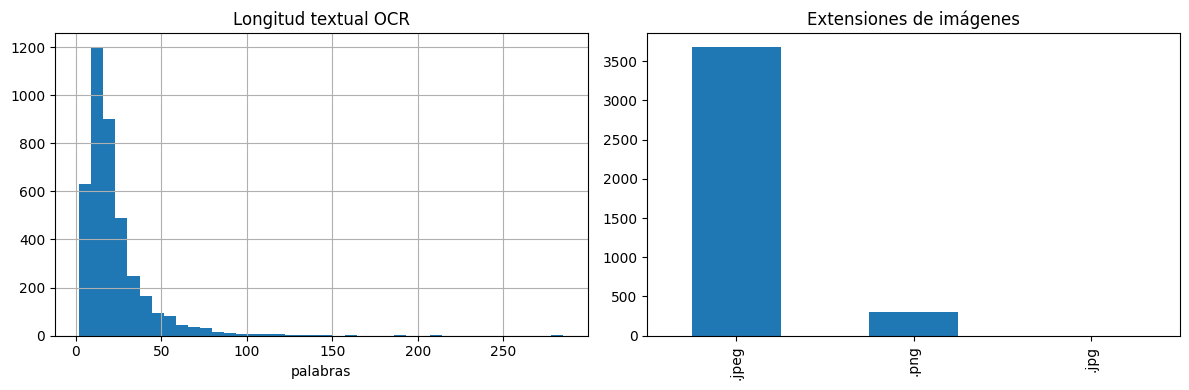

In [4]:
print("Train language distribution:", train_all_df["lang"].value_counts().to_dict())
print("Test language distribution:", test_df["lang"].value_counts().to_dict())
print("Train images found:", int(train_all_df["image_path"].astype(bool).sum()), "/", len(train_all_df))
print("Test images found:", int(test_df["image_path"].astype(bool).sum()), "/", len(test_df))
print("Empty training OCR texts:", int(train_all_df["text"].fillna("").str.len().eq(0).sum()))

display(train_all_df.groupby(["lang", "gold_2_1_hard"], dropna=False).size().rename("n").reset_index())
display(train_all_df.groupby(["lang", "gold_2_2_hard"], dropna=False).size().rename("n").reset_index())

facet_rows = []
for labels in train_all_df["gold_2_3_hard"].dropna():
    labels = labels if isinstance(labels, list) else [labels]
    for label in labels:
        facet_rows.append(label)
display(pd.Series(facet_rows).value_counts().rename_axis("label").reset_index(name="n"))

sensor_cols = [c for c in train_all_df.columns if c.startswith("sensorial_")]
print("Number of sensor features:", len(sensor_cols))
if sensor_cols:
    missing = train_all_df[sensor_cols].isna().mean().sort_values(ascending=False).head(20)
    display(missing.rename("missing_rate").reset_index().rename(columns={"index": "feature"}))

if plt is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    train_all_df["text_words"].hist(ax=axes[0], bins=40)
    axes[0].set_title("Longitud textual OCR")
    axes[0].set_xlabel("palabras")
    pd.Series([Path(p).suffix.lower() for p in train_all_df["image_path"] if p]).value_counts().plot(kind="bar", ax=axes[1])
    axes[1].set_title("Extensiones de imágenes")
    plt.tight_layout()

In [5]:
def get_sensor_columns(df):
    return [
        c for c in df.columns
        if (c.startswith("sensorial_") or c in {"lang_en", "lang_es"})
        and pd.api.types.is_numeric_dtype(df[c])
    ]


def sensor_matrices(train_df, dev_df, test_df):
    cols = get_sensor_columns(train_df)
    if not cols:
        return None, None, None, []
    pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
    X_train = pipe.fit_transform(train_df[cols])
    X_dev = pipe.transform(dev_df[cols])
    X_test = pipe.transform(test_df[cols])
    return X_train, X_dev, X_test, cols


def ids_hash(ids):
    text = "|".join(map(str, ids))
    return hashlib.md5(text.encode("utf-8")).hexdigest()[:12]


def make_sparse_preprocessor(representation="word_char", include_sensors=False):
    parts = []
    if representation in {"word", "word_char"}:
        parts.append(
            (
                "word",
                TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True),
                "model_text",
            )
        )
    if representation in {"char", "word_char"}:
        parts.append(
            (
                "char",
                TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, sublinear_tf=True),
                "model_text",
            )
        )
    if include_sensors:
        sensor_cols = get_sensor_columns(train_all_df)
        if sensor_cols:
            parts.append(
                (
                    "sensors",
                    Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler(with_mean=False))]),
                    sensor_cols,
                )
            )
    return ColumnTransformer(parts, remainder="drop", sparse_threshold=0.40)


def align_proba_columns(proba, estimator_classes, label_names):
    proba = np.asarray(proba, dtype=float)
    aligned = np.zeros((proba.shape[0], len(label_names)), dtype=float)
    for j, cls in enumerate(estimator_classes):
        if int(cls) < len(label_names):
            aligned[:, int(cls)] = proba[:, j]
    row_sum = aligned.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1.0
    return aligned / row_sum


def proba_from_estimator(estimator, X, label_names):
    if hasattr(estimator, "predict_proba"):
        proba = estimator.predict_proba(X)
        if isinstance(proba, list):
            if len(proba) == len(label_names) and proba[0].ndim == 2:
                return np.vstack([p[:, 1] for p in proba]).T
            proba = proba[0]
        classes = getattr(estimator, "classes_", np.arange(proba.shape[1]))
        return align_proba_columns(proba, classes, label_names)
    if hasattr(estimator, "decision_function"):
        scores = np.asarray(estimator.decision_function(X), dtype=float)
        if scores.ndim == 1:
            pos = expit(scores)
            return np.vstack([1 - pos, pos]).T
        return softmax(scores, axis=1)
    pred = estimator.predict(X)
    out = np.zeros((len(pred), len(label_names)), dtype=float)
    out[np.arange(len(pred)), pred.astype(int)] = 1.0
    return out


def fit_with_optional_weight(pipe, X, y, sample_weight=None):
    try:
        if sample_weight is not None:
            return pipe.fit(X, y, clf__sample_weight=sample_weight)
    except TypeError:
        pass
    return pipe.fit(X, y)


def optimize_binary_threshold(y_true, proba, positive_index=1):
    scores = np.asarray(proba)[:, positive_index]
    thresholds = np.unique(np.quantile(scores, np.linspace(0.02, 0.98, 97)))
    best_t, best_f1 = 0.5, -1.0
    for t in thresholds:
        pred = (scores >= t).astype(int)
        value = f1_score(y_true, pred, zero_division=0)
        if value > best_f1:
            best_t, best_f1 = float(t), float(value)
    return best_t, best_f1


def evaluate_single_label(y_true, proba, label_names, positive_index=None, threshold=None):
    proba = np.asarray(proba, dtype=float)
    if positive_index is not None:
        if threshold is None:
            threshold, _ = optimize_binary_threshold(y_true, proba, positive_index)
        pred = (proba[:, positive_index] >= threshold).astype(int)
    else:
        pred = proba.argmax(axis=1)
        threshold = np.nan
    result = {
        "accuracy": accuracy_score(y_true, pred),
        "macro_f1": f1_score(y_true, pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, pred, average="weighted", zero_division=0),
        "threshold": threshold,
        "report": classification_report(y_true, pred, target_names=label_names, zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, pred),
        "pred": pred,
    }
    if positive_index is not None:
        p, r, f, _ = precision_recall_fscore_support(y_true, pred, average="binary", zero_division=0)
        result.update({"positive_f1": f, "precision": p, "recall": r})
    return result


def postprocess_multilabel(scores, thresholds, label_names):
    scores = np.asarray(scores, dtype=float)
    thresholds = np.asarray(thresholds, dtype=float)
    pred = (scores >= thresholds.reshape(1, -1)).astype(int)
    if "NO" in label_names:
        no_idx = label_names.index("NO")
        facet_idx = [i for i, label in enumerate(label_names) if label != "NO"]
        facet_active = pred[:, facet_idx].sum(axis=1) > 0
        pred[facet_active, no_idx] = 0
        no_facet = ~facet_active
        pred[no_facet, :] = 0
        pred[no_facet, no_idx] = 1
    else:
        empty = pred.sum(axis=1) == 0
        pred[empty, np.argmax(scores[empty], axis=1)] = 1
    return pred


def optimize_multilabel_thresholds(y_true, scores, label_names):
    scores = np.asarray(scores, dtype=float)
    thresholds = np.full(scores.shape[1], 0.5, dtype=float)
    grid = np.linspace(0.10, 0.90, 33)
    for j in range(scores.shape[1]):
        best_t, best_f1 = 0.5, -1.0
        for t in grid:
            local = thresholds.copy()
            local[j] = t
            pred = postprocess_multilabel(scores, local, label_names)
            value = f1_score(y_true[:, j], pred[:, j], zero_division=0)
            if value > best_f1:
                best_t, best_f1 = float(t), float(value)
        thresholds[j] = best_t
    return thresholds



OFFICIAL_METRIC_KEYS = ["icm", "icm_norm", "f1_official", "icm_soft", "icm_soft_norm", "cross_entropy"]
_OFFICIAL_METRIC_WARNINGS_SHOWN = set()


def normalize_task_id(task_id="2_3"):
    task_id = str(task_id or "2_3")
    return task_id[4:] if task_id.startswith("task") else task_id


def official_metric_values(metrics):
    return {key: metrics.get(key, np.nan) for key in OFFICIAL_METRIC_KEYS}


def _warn_official_metric_once(key, message):
    if key not in _OFFICIAL_METRIC_WARNINGS_SHOWN:
        print(message)
        _OFFICIAL_METRIC_WARNINGS_SHOWN.add(key)


def _write_pyevall_json(path, records):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(records, f, ensure_ascii=False)


def _extract_pyevall_metric(report, metric_name):
    try:
        metric = report.report["metrics"][metric_name]
        value = metric["results"]["average_per_test_case"]
        return float(value) if value is not None else np.nan
    except Exception:
        return np.nan


def _labels_from_binary_row(row, label_names):
    labels = [label for label, active in zip(label_names, row) if int(active) == 1]
    if not labels:
        return ["NO"] if "NO" in label_names else []
    if "NO" in labels and len(labels) > 1:
        labels = [label for label in labels if label != "NO"]
    return labels


def _safe_multilabel_list(value, label_names, fallback=None):
    allowed = set(label_names)
    if isinstance(value, str):
        labels = [value] if value in allowed else []
    elif isinstance(value, (list, tuple, set)):
        labels = [label for label in value if label in allowed]
    else:
        labels = []
    if not labels and fallback is not None:
        labels = list(fallback)
    if not labels and "NO" in allowed:
        labels = ["NO"]
    if "NO" in labels and len(labels) > 1:
        labels = [label for label in labels if label != "NO"]
    return sorted(set(labels), key=label_names.index)


def _safe_multilabel_distribution(value, label_names, fallback_labels=None):
    out = {label: 0.0 for label in label_names}
    if isinstance(value, dict):
        for label in label_names:
            try:
                val = float(value.get(label, 0.0))
            except Exception:
                val = 0.0
            out[label] = float(np.clip(val, 0.0, 1.0)) if np.isfinite(val) else 0.0
    else:
        for label in (fallback_labels or []):
            if label in out:
                out[label] = 1.0
    return out


def compute_official_multilabel_metrics(y_true, scores, pred, label_names, eval_df=None, task_id="2_3"):
    """Calcula ICM, ICM-soft, F1 y Cross-entropy oficiales para Task 2.3 en validacion."""
    out = {key: np.nan for key in OFFICIAL_METRIC_KEYS}
    if PyEvALLEvaluation is None or MetricFactory is None or PyEvALLUtils is None:
        _warn_official_metric_once("pyevall_missing", "Aviso: PyEvALL no esta disponible; no se calculan ICM/ICM-Soft/Cross-Entropy.")
        return out

    task_id = normalize_task_id(task_id)
    test_case = f"task{task_id}"
    y_true = np.asarray(y_true, dtype=int)
    scores = np.clip(np.nan_to_num(np.asarray(scores, dtype=float), nan=0.0, posinf=1.0, neginf=0.0), 0.0, 1.0)
    pred = np.asarray(pred, dtype=int)
    if scores.ndim != 2 or scores.shape[1] != len(label_names) or pred.shape != y_true.shape:
        return out

    ids = [str(x) for x in eval_df["id_EXIST"].tolist()] if eval_df is not None and "id_EXIST" in eval_df.columns and len(eval_df) == len(y_true) else [str(i) for i in range(len(y_true))]
    hard_col = f"gold_{task_id}_hard"
    soft_col = f"gold_{task_id}_soft"
    hard_gold, hard_pred, soft_gold, soft_pred = [], [], [], []

    for i, item_id in enumerate(ids):
        fallback_gold = _labels_from_binary_row(y_true[i], label_names)
        fallback_pred = _labels_from_binary_row(pred[i], label_names)
        hard_value = fallback_gold
        soft_value = None
        if eval_df is not None and len(eval_df) == len(y_true):
            if hard_col in eval_df.columns:
                hard_value = _safe_multilabel_list(eval_df.iloc[i].get(hard_col), label_names, fallback=fallback_gold)
            if soft_col in eval_df.columns:
                soft_value = eval_df.iloc[i].get(soft_col)
        hard_gold.append({"test_case": test_case, "id": item_id, "value": _safe_multilabel_list(hard_value, label_names, fallback=fallback_gold)})
        hard_pred.append({"test_case": test_case, "id": item_id, "value": fallback_pred})
        soft_gold.append({"test_case": test_case, "id": item_id, "value": _safe_multilabel_distribution(soft_value, label_names, fallback_labels=fallback_gold)})
        soft_pred.append({"test_case": test_case, "id": item_id, "value": {label: float(scores[i, j]) for j, label in enumerate(label_names)}})

    hierarchy = {label: [] for label in label_names}
    with tempfile.TemporaryDirectory() as tmpdir:
        tmpdir = Path(tmpdir)
        hard_gold_path, hard_pred_path = tmpdir / "gold_hard.json", tmpdir / "pred_hard.json"
        soft_gold_path, soft_pred_path = tmpdir / "gold_soft.json", tmpdir / "pred_soft.json"
        _write_pyevall_json(hard_gold_path, hard_gold)
        _write_pyevall_json(hard_pred_path, hard_pred)
        _write_pyevall_json(soft_gold_path, soft_gold)
        _write_pyevall_json(soft_pred_path, soft_pred)
        try:
            report = PyEvALLEvaluation().evaluate(str(hard_pred_path), str(hard_gold_path), [MetricFactory.ICM.value, MetricFactory.ICMNorm.value], hierarchy=hierarchy, report=PyEvALLUtils.PARAM_OPTION_REPORT_SIMPLE, log_level=PyEvALLUtils.PARAM_OPTION_LOG_LEVEL_NONE)
            out["icm"] = _extract_pyevall_metric(report, MetricFactory.ICM.value)
            out["icm_norm"] = _extract_pyevall_metric(report, MetricFactory.ICMNorm.value)
        except Exception as exc:
            _warn_official_metric_once("pyevall_hard_icm", f"Aviso: PyEvALL ICM hard no pudo calcularse: {type(exc).__name__}: {exc}")
        try:
            report = PyEvALLEvaluation().evaluate(str(hard_pred_path), str(hard_gold_path), [MetricFactory.FMeasure.value], report=PyEvALLUtils.PARAM_OPTION_REPORT_SIMPLE, log_level=PyEvALLUtils.PARAM_OPTION_LOG_LEVEL_NONE)
            out["f1_official"] = _extract_pyevall_metric(report, MetricFactory.FMeasure.value)
        except Exception as exc:
            _warn_official_metric_once("pyevall_hard_f1", f"Aviso: PyEvALL F1 hard no pudo calcularse: {type(exc).__name__}: {exc}")
        try:
            report = PyEvALLEvaluation().evaluate(str(soft_pred_path), str(soft_gold_path), [MetricFactory.ICMSoft.value, MetricFactory.ICMSoftNorm.value, MetricFactory.CrossEntropy.value], report=PyEvALLUtils.PARAM_OPTION_REPORT_SIMPLE, log_level=PyEvALLUtils.PARAM_OPTION_LOG_LEVEL_NONE)
            out["icm_soft"] = _extract_pyevall_metric(report, MetricFactory.ICMSoft.value)
            out["icm_soft_norm"] = _extract_pyevall_metric(report, MetricFactory.ICMSoftNorm.value)
            out["cross_entropy"] = _extract_pyevall_metric(report, MetricFactory.CrossEntropy.value)
        except Exception as exc:
            _warn_official_metric_once("pyevall_soft", f"Aviso: PyEvALL soft no pudo calcularse: {type(exc).__name__}: {exc}")
    return out


def evaluate_multilabel(y_true, scores, label_names, thresholds=None, eval_df=None, task_id="2_3"):
    scores = np.clip(np.nan_to_num(np.asarray(scores, dtype=float), nan=0.0, posinf=1.0, neginf=0.0), 0.0, 1.0)
    if thresholds is None:
        thresholds = optimize_multilabel_thresholds(y_true, scores, label_names)
    pred = postprocess_multilabel(scores, thresholds, label_names)
    facet_idx = [i for i, label in enumerate(label_names) if label != "NO"]
    result = {
        "macro_f1": f1_score(y_true, pred, average="macro", zero_division=0),
        "micro_f1": f1_score(y_true, pred, average="micro", zero_division=0),
        "samples_f1": f1_score(y_true, pred, average="samples", zero_division=0),
        "facet_macro_f1": f1_score(y_true[:, facet_idx], pred[:, facet_idx], average="macro", zero_division=0),
        "thresholds": thresholds,
        "report": classification_report(y_true, pred, target_names=label_names, zero_division=0),
        "pred": pred,
    }
    if eval_df is not None:
        result.update(compute_official_multilabel_metrics(y_true, scores, pred, label_names, eval_df=eval_df, task_id=task_id))
    return result


def score_artifact_path(output_prefix, run_name):
    return PREDICTION_ARTIFACTS_DIR / output_prefix / f"{slug(run_name)}_scores.npz"


def metadata_artifact_path(output_prefix, run_name):
    return PREDICTION_ARTIFACTS_DIR / output_prefix / f"{slug(run_name)}_metadata.json"


def save_score_artifact(output_prefix, run_name, dev_scores, test_scores, thresholds=None, metadata=None):
    folder = PREDICTION_ARTIFACTS_DIR / output_prefix
    folder.mkdir(parents=True, exist_ok=True)
    path = score_artifact_path(output_prefix, run_name)
    payload = {"dev": np.asarray(dev_scores, dtype=np.float32), "test": np.asarray(test_scores, dtype=np.float32)}
    if thresholds is not None:
        payload["thresholds"] = np.asarray(thresholds, dtype=np.float32)
    np.savez_compressed(path, **payload)
    meta = dict(metadata or {})
    meta.update({"run_name": run_name, "score_path": str(path), "saved_at": time.strftime("%Y-%m-%d %H:%M:%S")})
    with open(metadata_artifact_path(output_prefix, run_name), "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)
    return path


def load_score_artifact(output_prefix, run_name, expected_dev_rows, expected_test_rows, n_labels):
    path = score_artifact_path(output_prefix, run_name)
    if not path.exists():
        return None
    try:
        data = np.load(path)
        dev = np.asarray(data["dev"], dtype=np.float32)
        test = np.asarray(data["test"], dtype=np.float32)
        if dev.shape != (expected_dev_rows, n_labels) or test.shape != (expected_test_rows, n_labels):
            return None
        thresholds = np.asarray(data["thresholds"], dtype=np.float32) if "thresholds" in data.files else None
        print(f"Reused score cache for {run_name}: {path}")
        return dev, test, thresholds
    except Exception as exc:
        print(f"Cache de scores invalida para {run_name}: {type(exc).__name__}: {exc}")
        return None


def save_model_artifact(model, output_prefix, run_name, subdir="sklearn", metadata=None):
    folder = MODEL_ARTIFACTS_DIR / output_prefix / subdir
    folder.mkdir(parents=True, exist_ok=True)
    path = folder / f"{slug(run_name)}.joblib"
    joblib.dump({"model": model, "metadata": metadata or {}}, path)
    return path


In [6]:
def tensor_from_model_output(outputs, prefer_image_embeds=True):
    """Extrae un tensor 2D desde salidas de Hugging Face/CLIP."""
    if isinstance(outputs, torch.Tensor):
        tensor = outputs
    elif prefer_image_embeds and hasattr(outputs, "image_embeds") and outputs.image_embeds is not None:
        tensor = outputs.image_embeds
    elif hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
        tensor = outputs.pooler_output
    elif hasattr(outputs, "last_hidden_state") and outputs.last_hidden_state is not None:
        tensor = outputs.last_hidden_state[:, 0]
    elif isinstance(outputs, (tuple, list)) and outputs:
        tensor = outputs[0]
    else:
        raise TypeError(f"No se pudo extraer tensor desde salida {type(outputs)}")

    if isinstance(tensor, (tuple, list)) and tensor:
        tensor = tensor[0]
    if not isinstance(tensor, torch.Tensor):
        raise TypeError(f"La salida extraida no es tensor: {type(tensor)}")
    if tensor.ndim == 3:
        tensor = tensor[:, 0]
    if tensor.ndim != 2:
        raise ValueError(f"El tensor de embeddings debe ser 2D, recibido shape={tuple(tensor.shape)}")
    return tensor


def safe_linear_projection(layer, tensor, layer_name="projection"):
    """Aplica una capa lineal solo si el tensor todavia no esta proyectado."""
    if layer is None:
        return tensor
    in_features = int(getattr(layer, "in_features", 0) or 0)
    out_features = int(getattr(layer, "out_features", 0) or 0)
    weight = getattr(layer, "weight", None)
    if weight is not None:
        if out_features <= 0:
            out_features = int(weight.shape[0])
        if in_features <= 0:
            in_features = int(weight.shape[1])

    last_dim = int(tensor.shape[-1])
    if out_features > 0 and last_dim == out_features:
        return tensor
    if in_features > 0 and last_dim == in_features:
        return layer(tensor)
    raise RuntimeError(
        f"{layer_name}: dimension incompatible. Tensor={tuple(tensor.shape)}, "
        f"Linear espera in_features={in_features}, out_features={out_features}."
    )


def encode_sentence_model(model_name, train_df, dev_df, test_df):
    from sentence_transformers import SentenceTransformer

    key = f"{slug(model_name)}_{ids_hash(train_df.id_EXIST)}_{ids_hash(dev_df.id_EXIST)}_{ids_hash(test_df.id_EXIST)}"
    train_cache = CACHE_DIR / f"sent_{key}_train.npy"
    dev_cache = CACHE_DIR / f"sent_{key}_dev.npy"
    test_cache = CACHE_DIR / f"sent_{key}_test.npy"
    train_pcache = DRIVE_EMB_CACHE_DIR / f"sent_{key}_train.npy"
    dev_pcache = DRIVE_EMB_CACHE_DIR / f"sent_{key}_dev.npy"
    test_pcache = DRIVE_EMB_CACHE_DIR / f"sent_{key}_test.npy"
    if train_cache.exists() and dev_cache.exists() and test_cache.exists():
        return np.load(train_cache), np.load(dev_cache), np.load(test_cache)
    if train_pcache.exists() and dev_pcache.exists() and test_pcache.exists():
        X_train, X_dev, X_test = np.load(train_pcache), np.load(dev_pcache), np.load(test_pcache)
        np.save(train_cache, X_train); np.save(dev_cache, X_dev); np.save(test_cache, X_test)
        return X_train, X_dev, X_test

    model = SentenceTransformer(model_name, device=DEVICE, cache_folder=str(SENTENCE_TRANSFORMERS_HOME))
    def prep(texts):
        if "e5" in model_name.lower():
            return [f"query: {text}" for text in texts]
        return list(map(str, texts))

    X_train = model.encode(prep(train_df["model_text"]), batch_size=TEXT_EMBED_BATCH_SIZE, normalize_embeddings=True, show_progress_bar=True)
    X_dev = model.encode(prep(dev_df["model_text"]), batch_size=TEXT_EMBED_BATCH_SIZE, normalize_embeddings=True, show_progress_bar=True)
    X_test = model.encode(prep(test_df["model_text"]), batch_size=TEXT_EMBED_BATCH_SIZE, normalize_embeddings=True, show_progress_bar=True)
    for path, arr in [(train_cache, X_train), (dev_cache, X_dev), (test_cache, X_test), (train_pcache, X_train), (dev_pcache, X_dev), (test_pcache, X_test)]:
        np.save(path, arr)
    return X_train, X_dev, X_test


def encode_image_model(model_name, train_df, dev_df, test_df):
    if torch is None:
        print("PyTorch no disponible; se omiten embeddings de imagen.")
        return None, None, None
    from PIL import Image

    key = f"{slug(model_name)}_{ids_hash(train_df.id_EXIST)}_{ids_hash(dev_df.id_EXIST)}_{ids_hash(test_df.id_EXIST)}"
    train_cache = CACHE_DIR / f"img_{key}_train.npy"
    dev_cache = CACHE_DIR / f"img_{key}_dev.npy"
    test_cache = CACHE_DIR / f"img_{key}_test.npy"
    train_pcache = DRIVE_EMB_CACHE_DIR / f"img_{key}_train.npy"
    dev_pcache = DRIVE_EMB_CACHE_DIR / f"img_{key}_dev.npy"
    test_pcache = DRIVE_EMB_CACHE_DIR / f"img_{key}_test.npy"
    if train_cache.exists() and dev_cache.exists() and test_cache.exists():
        return np.load(train_cache), np.load(dev_cache), np.load(test_cache)
    if train_pcache.exists() and dev_pcache.exists() and test_pcache.exists():
        X_train, X_dev, X_test = np.load(train_pcache), np.load(dev_pcache), np.load(test_pcache)
        np.save(train_cache, X_train); np.save(dev_cache, X_dev); np.save(test_cache, X_test)
        return X_train, X_dev, X_test

    all_paths = list(train_df["image_path"]) + list(dev_df["image_path"]) + list(test_df["image_path"])
    missing = sum(not bool(p) or not Path(p).exists() for p in all_paths)
    if missing:
        print(f"Aviso: faltan {missing}/{len(all_paths)} imágenes; se usarán vectores cero para esas filas.")

    if "clip" in model_name.lower():
        processor = CLIPProcessor.from_pretrained(model_name, cache_dir=str(HF_HUB_CACHE))
        model = CLIPModel.from_pretrained(model_name, cache_dir=str(HF_HUB_CACHE)).to(DEVICE)
        output_dim = int(getattr(model.config, "projection_dim", 512))

        def encode_batch(images):
            inputs = processor(images=images, return_tensors="pt")
            inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
            with torch.no_grad():
                # En transformers recientes get_image_features devuelve un ModelOutput,
                # no un tensor. Usamos la ruta visual manual y proyectamos solo si toca.
                vision_outputs = model.vision_model(pixel_values=inputs["pixel_values"])
                pooled = tensor_from_model_output(vision_outputs, prefer_image_embeds=False)
                feats = safe_linear_projection(getattr(model, "visual_projection", None), pooled, "CLIP visual_projection")
                feats = torch.nn.functional.normalize(feats, p=2, dim=1)
            return feats.detach().cpu().numpy().astype(np.float32)
    else:
        processor = AutoImageProcessor.from_pretrained(model_name, cache_dir=str(HF_HUB_CACHE))
        model = AutoModel.from_pretrained(model_name, cache_dir=str(HF_HUB_CACHE)).to(DEVICE)
        output_dim = getattr(model.config, "hidden_size", 768)

        def encode_batch(images):
            inputs = processor(images=images, return_tensors="pt")
            inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
            with torch.no_grad():
                outputs = model(**inputs)
                feats = tensor_from_model_output(outputs, prefer_image_embeds=False)
                feats = torch.nn.functional.normalize(feats, p=2, dim=1)
            return feats.detach().cpu().numpy().astype(np.float32)

    model.eval()

    def encode_frame(frame, batch_size=IMAGE_EMBED_BATCH_SIZE):
        vectors = []
        pending_images = []
        pending_positions = []
        output = np.zeros((len(frame), output_dim), dtype=np.float32)
        for i, path_value in enumerate(frame["image_path"]):
            path = Path(path_value) if path_value else None
            if path is None or not path.exists():
                continue
            try:
                pending_images.append(Image.open(path).convert("RGB"))
                pending_positions.append(i)
            except Exception:
                continue
            if len(pending_images) == batch_size:
                output[pending_positions] = encode_batch(pending_images)
                pending_images, pending_positions = [], []
        if pending_images:
            output[pending_positions] = encode_batch(pending_images)
        return output

    X_train = encode_frame(train_df)
    X_dev = encode_frame(dev_df)
    X_test = encode_frame(test_df)
    for path, arr in [(train_cache, X_train), (dev_cache, X_dev), (test_cache, X_test), (train_pcache, X_train), (dev_pcache, X_dev), (test_pcache, X_test)]:
        np.save(path, arr)
    del model
    gc.collect()
    if torch is not None and torch.cuda.is_available():
        torch.cuda.empty_cache()
    return X_train, X_dev, X_test


def build_dense_fusion(train_df, dev_df, test_df, modality, text_model=None, image_model=None):
    blocks_train, blocks_dev, blocks_test = [], [], []
    if "text" in modality:
        Xtr, Xdv, Xte = encode_sentence_model(text_model, train_df, dev_df, test_df)
        blocks_train.append(Xtr)
        blocks_dev.append(Xdv)
        blocks_test.append(Xte)
    if "image" in modality:
        Xtr, Xdv, Xte = encode_image_model(image_model, train_df, dev_df, test_df)
        if Xtr is None:
            return None, None, None
        blocks_train.append(Xtr)
        blocks_dev.append(Xdv)
        blocks_test.append(Xte)
    if "sensor" in modality:
        Xtr, Xdv, Xte, sensor_cols = sensor_matrices(train_df, dev_df, test_df)
        if Xtr is not None:
            blocks_train.append(Xtr)
            blocks_dev.append(Xdv)
            blocks_test.append(Xte)
    if not blocks_train:
        return None, None, None
    return np.hstack(blocks_train), np.hstack(blocks_dev), np.hstack(blocks_test)

In [7]:
def multilabel_scores_from_estimator(estimator, X, label_names):
    if hasattr(estimator, "predict_proba"):
        proba = estimator.predict_proba(X)
        if isinstance(proba, list):
            return np.vstack([p[:, 1] if p.ndim == 2 else p.ravel() for p in proba]).T
        proba = np.asarray(proba)
        if proba.ndim == 3:
            return proba[:, :, 1].T
        return proba
    if hasattr(estimator, "decision_function"):
        return expit(np.asarray(estimator.decision_function(X), dtype=float))
    return np.asarray(estimator.predict(X), dtype=float)


def _multilabel_result_row(run_name, modality, metrics, runtime_seconds=0.0, cache_hit=False, **extra):
    row = {
        "model": run_name,
        "modality": modality,
        "macro_f1": metrics["macro_f1"],
        "facet_macro_f1": metrics["facet_macro_f1"],
        "micro_f1": metrics["micro_f1"],
        "samples_f1": metrics["samples_f1"],
        "thresholds": ",".join(f"{t:.3f}" for t in metrics["thresholds"]),
        "runtime_seconds": round(float(runtime_seconds), 2),
        "cache_hit": bool(cache_hit),
    }
    row.update(extra)
    row.update(official_metric_values(metrics))
    return row


def run_sparse_multilabel(train_df, dev_df, test_df, y_train, y_dev, label_names, output_prefix="task"):
    rows, bank = [], {}
    configs = []
    for rep in ["word", "char", "word_char"]:
        configs.extend([
            (f"text_{rep}_ovr_multinomial_nb", rep, False, OneVsRestClassifier(MultinomialNB(alpha=0.25))),
            (f"text_{rep}_ovr_complement_nb", rep, False, OneVsRestClassifier(ComplementNB(alpha=0.50))),
            (f"text_{rep}_ovr_lr_c2", rep, False, OneVsRestClassifier(LogisticRegression(max_iter=4000, C=2.0, class_weight="balanced", solver="liblinear", random_state=SEED))),
            (f"text_{rep}_chain_lr_c1", rep, False, ClassifierChain(LogisticRegression(max_iter=4000, C=1.0, class_weight="balanced", solver="liblinear", random_state=SEED), order="random", random_state=SEED)),
        ])
    for rep in ["word", "char", "word_char"]:
        configs.extend([
            (f"text_sensor_{rep}_ovr_lr_c2", rep, True, OneVsRestClassifier(LogisticRegression(max_iter=4000, C=2.0, class_weight="balanced", solver="liblinear", random_state=SEED))),
            (f"text_sensor_{rep}_chain_lr_c1", rep, True, ClassifierChain(LogisticRegression(max_iter=4000, C=1.0, class_weight="balanced", solver="liblinear", random_state=SEED), order="random", random_state=SEED)),
        ])
    if RUN_HEAVY_TREE_MODELS:
        configs.extend([
            ("text_word_char_svd_extra_trees", "word_char", False, ExtraTreesClassifier(n_estimators=500, class_weight="balanced", random_state=SEED, n_jobs=-1), True),
            ("text_sensor_word_char_svd_extra_trees", "word_char", True, ExtraTreesClassifier(n_estimators=500, class_weight="balanced", random_state=SEED, n_jobs=-1), True),
        ])
    configs = [tuple(list(c) + [False]) if len(c) == 4 else c for c in configs]
    if QUICK_DEBUG:
        configs = configs[:5]

    for name, rep, include_sensors, clf, use_svd in configs:
        start = time.time()
        cached = load_score_artifact(output_prefix, name, len(dev_df), len(test_df), len(label_names))
        if cached is not None:
            dev_scores, test_scores, thresholds = cached
            metrics = evaluate_multilabel(y_dev, dev_scores, label_names, thresholds=thresholds, eval_df=dev_df, task_id="2_3")
            rows.append(_multilabel_result_row(name, "text+sensors" if include_sensors else "text", metrics, cache_hit=True))
            bank[name] = {"dev": dev_scores, "test": test_scores, "thresholds": metrics["thresholds"], "modality": "text+sensors" if include_sensors else "text"}
            continue

        steps = [("prep", make_sparse_preprocessor(rep, include_sensors))]
        if use_svd:
            steps.extend([("svd", TruncatedSVD(n_components=256, random_state=SEED)), ("scale", StandardScaler())])
        steps.append(("clf", clf))
        pipe = Pipeline(steps)
        pipe.fit(train_df, y_train)
        dev_scores = multilabel_scores_from_estimator(pipe, dev_df, label_names)
        test_scores = multilabel_scores_from_estimator(pipe, test_df, label_names)
        metrics = evaluate_multilabel(y_dev, dev_scores, label_names, eval_df=dev_df, task_id="2_3")
        save_model_artifact(pipe, output_prefix, name, subdir="sparse", metadata={"representation": rep, "include_sensors": include_sensors, "labels": list(label_names)})
        save_score_artifact(output_prefix, name, dev_scores, test_scores, thresholds=metrics["thresholds"], metadata={"kind": "sparse", "representation": rep, "include_sensors": include_sensors})
        rows.append(_multilabel_result_row(name, "text+sensors" if include_sensors else "text", metrics, time.time() - start, cache_hit=False))
        bank[name] = {"dev": dev_scores, "test": test_scores, "thresholds": metrics["thresholds"], "modality": "text+sensors" if include_sensors else "text"}

    result = pd.DataFrame(rows)
    if result.empty:
        return result, bank
    result = result.sort_values("facet_macro_f1", ascending=False).reset_index(drop=True)
    display(result)
    result.to_csv(OUTPUT_DIR / f"{output_prefix}_sparse_results.csv", index=False)
    return result, bank


def run_dense_multilabel(train_df, dev_df, test_df, y_train, y_dev, label_names, output_prefix="task"):
    if not RUN_DENSE_EMBEDDINGS:
        print("RUN_DENSE_EMBEDDINGS=False; se omiten embeddings densos.")
        return pd.DataFrame(), {}
    text_models = ["sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2", "intfloat/multilingual-e5-base"]
    if FULL_MODULAR and not QUICK_DEBUG:
        text_models.append("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")
    image_models = ["openai/clip-vit-base-patch32"]
    if RUN_HEAVY_DINO:
        image_models.append("facebook/dinov2-base")
    modality_specs = []
    for tm in text_models:
        modality_specs.append(("text", tm, None))
        modality_specs.append(("text+sensor", tm, None))
    if RUN_IMAGE_EMBEDDINGS:
        for im in image_models:
            modality_specs.append(("image", None, im))
            for tm in text_models[:2]:
                modality_specs.append(("text+image", tm, im))
                modality_specs.append(("text+image+sensor", tm, im))
    if QUICK_DEBUG:
        modality_specs = modality_specs[:4]

    rows, bank, failed_runs = [], {}, []
    for modality, text_model, image_model in modality_specs:
        print("Dense multilabel modality:", modality, text_model, image_model)
        try:
            X_train, X_dev, X_test = build_dense_fusion(train_df, dev_df, test_df, modality, text_model, image_model)
        except Exception as exc:
            failed_runs.append({
                "stage": "build_dense_fusion",
                "modality": modality,
                "text_model": text_model or "",
                "image_model": image_model or "",
                "error_type": type(exc).__name__,
                "error": str(exc),
            })
            print(f"Saltada modalidad densa {modality} ({text_model}, {image_model}) por {type(exc).__name__}: {exc}")
            if torch is not None and torch.cuda.is_available():
                torch.cuda.empty_cache()
            gc.collect()
            continue
        if X_train is None:
            continue
        classifiers = [
            ("ovr_lr_c1", OneVsRestClassifier(LogisticRegression(max_iter=4000, C=1.0, class_weight="balanced", solver="liblinear", random_state=SEED))),
            ("ovr_lr_c3", OneVsRestClassifier(LogisticRegression(max_iter=4000, C=3.0, class_weight="balanced", solver="liblinear", random_state=SEED))),
            ("chain_lr_c1", ClassifierChain(LogisticRegression(max_iter=4000, C=1.0, class_weight="balanced", solver="liblinear", random_state=SEED), order="random", random_state=SEED)),
        ]
        if RUN_HEAVY_TREE_MODELS:
            classifiers.append(("extra_trees", ExtraTreesClassifier(n_estimators=500, class_weight="balanced", random_state=SEED, n_jobs=-1)))
            classifiers.append(("mlp", MLPClassifier(hidden_layer_sizes=(256,), alpha=1e-4, early_stopping=True, max_iter=200, random_state=SEED)))
        for clf_name, clf in classifiers:
            start = time.time()
            run_name = f"{modality}_{slug(text_model or 'no_text')}_{slug(image_model or 'no_image')}_{clf_name}"
            cached = load_score_artifact(output_prefix, run_name, len(dev_df), len(test_df), len(label_names))
            if cached is not None:
                dev_scores, test_scores, thresholds = cached
                metrics = evaluate_multilabel(y_dev, dev_scores, label_names, thresholds=thresholds, eval_df=dev_df, task_id="2_3")
                rows.append(_multilabel_result_row(run_name, modality.replace("sensor", "sensors"), metrics, cache_hit=True, text_model=text_model or "", image_model=image_model or "", classifier=clf_name))
                bank[run_name] = {"dev": dev_scores, "test": test_scores, "thresholds": metrics["thresholds"], "modality": modality.replace("sensor", "sensors")}
                continue

            local_clf = clone(clf)
            local_clf.fit(X_train, y_train)
            dev_scores = multilabel_scores_from_estimator(local_clf, X_dev, label_names)
            test_scores = multilabel_scores_from_estimator(local_clf, X_test, label_names)
            metrics = evaluate_multilabel(y_dev, dev_scores, label_names, eval_df=dev_df, task_id="2_3")
            save_model_artifact(local_clf, output_prefix, run_name, subdir="dense", metadata={"modality": modality, "text_model": text_model or "", "image_model": image_model or "", "classifier": clf_name, "labels": list(label_names)})
            save_score_artifact(output_prefix, run_name, dev_scores, test_scores, thresholds=metrics["thresholds"], metadata={"kind": "dense", "modality": modality, "text_model": text_model or "", "image_model": image_model or "", "classifier": clf_name})
            rows.append(_multilabel_result_row(run_name, modality.replace("sensor", "sensors"), metrics, time.time() - start, cache_hit=False, text_model=text_model or "", image_model=image_model or "", classifier=clf_name))
            bank[run_name] = {"dev": dev_scores, "test": test_scores, "thresholds": metrics["thresholds"], "modality": modality.replace("sensor", "sensors")}
    failed_path = OUTPUT_DIR / f"{output_prefix}_dense_failed_runs.csv"
    if failed_runs:
        failed = pd.DataFrame(failed_runs)
        failed.to_csv(failed_path, index=False)
        print(f"Aviso: {len(failed_runs)} modalidades densas se saltaron y quedaron registradas en {failed_path}")
        display(failed.tail(20))
    else:
        failed_path.unlink(missing_ok=True)

    result = pd.DataFrame(rows)
    if result.empty:
        return result, bank
    result = result.sort_values("facet_macro_f1", ascending=False).reset_index(drop=True)
    display(result)
    result.to_csv(OUTPUT_DIR / f"{output_prefix}_dense_multimodal_results.csv", index=False)
    return result, bank


def ensemble_multilabel(y_dev, label_names, banks, output_prefix="task", eval_df=None, task_id=None):
    merged = {name: value for bank in banks for name, value in bank.items()}
    if len(merged) < 2:
        print("No hay suficientes modelos para ensemble multilabel.")
        return None, None, None
    label_prior = y_dev.mean(axis=0)

    def fill_missing_scores(scores):
        scores = np.asarray(scores, dtype=float).copy()
        bad_rows = ~np.isfinite(scores).all(axis=1)
        if bad_rows.any():
            scores[bad_rows] = label_prior
        return np.clip(scores, 0.0, 1.0)

    rows = []
    for name, value in merged.items():
        dev_scores = np.asarray(value["dev"], dtype=float)
        coverage_mask = np.isfinite(dev_scores).all(axis=1)
        if coverage_mask.sum() < max(10, len(y_dev) // 10):
            continue
        local_eval_df = eval_df.iloc[np.asarray(coverage_mask)].reset_index(drop=True) if eval_df is not None and len(eval_df) == len(y_dev) else None
        metrics = evaluate_multilabel(y_dev[coverage_mask], dev_scores[coverage_mask], label_names, thresholds=value.get("thresholds"), eval_df=local_eval_df, task_id=task_id or output_prefix)
        row = {
            "model": name,
            "modality": value.get("modality", ""),
            "macro_f1": metrics["macro_f1"],
            "facet_macro_f1": metrics["facet_macro_f1"],
            "micro_f1": metrics["micro_f1"],
            "coverage": float(coverage_mask.mean()),
        }
        row.update(official_metric_values(metrics))
        rows.append(row)
    if not rows:
        print("No hay matrices de scores con cobertura suficiente para ensemble multilabel.")
        return None, None, None
    rank = pd.DataFrame(rows).sort_values(["facet_macro_f1", "coverage"], ascending=[False, False]).reset_index(drop=True)
    display(rank.head(20))
    rank.to_csv(OUTPUT_DIR / f"{output_prefix}_ensemble_model_rank.csv", index=False)
    top_names = rank.head(min(8, len(rank)))["model"].tolist()
    avg_dev = np.stack([fill_missing_scores(merged[n]["dev"]) for n in top_names], axis=0).mean(axis=0)
    avg_test = np.stack([fill_missing_scores(merged[n]["test"]) for n in top_names], axis=0).mean(axis=0)
    metrics = evaluate_multilabel(y_dev, avg_dev, label_names, eval_df=eval_df, task_id=task_id or output_prefix)
    save_score_artifact(output_prefix, "ensemble_soft_vote", avg_dev, avg_test, thresholds=metrics["thresholds"], metadata={"kind": "ensemble", "top_models": top_names})
    with open(OUTPUT_DIR / f"{output_prefix}_ensemble_top_models.json", "w", encoding="utf-8") as f:
        json.dump({"top_models": top_names}, f, ensure_ascii=False, indent=2)
    print("Ensemble multilabel top models:", top_names)
    print(metrics["report"])
    return avg_dev, avg_test, metrics


In [15]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=192, multilabel=False):
        self.texts = list(map(str, texts))
        self.labels = None if labels is None else np.asarray(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.multilabel = multilabel

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        item = self.tokenizer(self.texts[idx], truncation=True, max_length=self.max_length)
        if self.labels is not None:
            item["labels"] = self.labels[idx].astype(np.float32) if self.multilabel else int(self.labels[idx])
        return item


class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, pos_weight=None, multilabel=False, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.pos_weight = pos_weight
        self.multilabel = multilabel

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        if self.multilabel:
            labels = labels.to(device=logits.device, dtype=logits.dtype)
            pos_weight = self.pos_weight.to(device=logits.device, dtype=logits.dtype) if self.pos_weight is not None else None
            loss = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)(logits, labels)
        else:
            labels = labels.to(device=logits.device)
            weights = self.class_weights.to(device=logits.device, dtype=logits.dtype) if self.class_weights is not None else None
            loss = torch.nn.CrossEntropyLoss(weight=weights, label_smoothing=0.03)(logits, labels)
        return (loss, outputs) if return_outputs else loss


def training_args(output_dir, metric_name, epochs=4, lr=2e-5, fp16=None):
    import inspect
    kwargs = dict(
        output_dir=str(output_dir),
        overwrite_output_dir=True,
        num_train_epochs=epochs,
        learning_rate=lr,
        per_device_train_batch_size=TRANSFORMER_TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=TRANSFORMER_EVAL_BATCH_SIZE,
        gradient_accumulation_steps=TRANSFORMER_GRAD_ACCUM_STEPS,
        weight_decay=0.01,
        logging_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model=metric_name,
        greater_is_better=True,
        report_to="none",
        seed=SEED,
        data_seed=SEED,
        fp16=bool((USE_MIXED_PRECISION if fp16 is None else fp16) and DEVICE == "cuda"),
        dataloader_num_workers=0,
        dataloader_pin_memory=bool(DEVICE == "cuda"),
        remove_unused_columns=True,
    )
    sig = inspect.signature(TrainingArguments.__init__)
    kwargs["eval_strategy" if "eval_strategy" in sig.parameters else "evaluation_strategy"] = "epoch"
    kwargs = {k: v for k, v in kwargs.items() if k in sig.parameters}
    return TrainingArguments(**kwargs)


def trainer_tokenizer_kwargs(tokenizer):
    import inspect
    params = inspect.signature(Trainer.__init__).parameters
    if "processing_class" in params:
        return {"processing_class": tokenizer}
    if "tokenizer" in params:
        return {"tokenizer": tokenizer}
    return {}


def transformer_candidates(task_kind):
    base = [
        {"scope": "all", "model": "FacebookAI/xlm-roberta-base", "epochs": 5, "lr": 2e-5},
        {"scope": "all", "model": "microsoft/mdeberta-v3-base", "epochs": 5, "lr": 2e-5, "fp16": False},
        {"scope": "en", "model": "cardiffnlp/twitter-roberta-base-offensive", "epochs": 5, "lr": 2e-5},
        {"scope": "es", "model": "dccuchile/bert-base-spanish-wwm-cased", "epochs": 5, "lr": 2e-5},
    ]
    if QUICK_DEBUG:
        return base[:1]
    if FULL_MODULAR:
        pass
    return base


def _np_float32_2d(x, name="array"):
    arr = np.asarray(x, dtype=np.float32)
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    if arr.ndim != 2:
        raise ValueError(f"{name} debe ser 2D, recibido shape={arr.shape}")
    return np.nan_to_num(arr, nan=0.0, posinf=1.0, neginf=0.0)


def language_mask(df, scope):
    if scope == "all":
        return np.ones(len(df), dtype=bool)
    if "lang" not in df.columns:
        return np.zeros(len(df), dtype=bool)
    return df["lang"].fillna("").astype(str).str.lower().eq(scope).to_numpy()


def save_trainer_history(trainer, output_dir):
    history = pd.DataFrame(trainer.state.log_history)
    if history.empty:
        return history
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    history_path = output_dir / "training_history.csv"
    history.to_csv(history_path, index=False)
    metric_cols = [c for c in ["epoch", "loss", "eval_loss", "eval_macro_f1", "eval_facet_macro_f1", "eval_micro_f1", "learning_rate"] if c in history.columns]
    if metric_cols:
        print("Historial de entrenamiento:")
        display(history[metric_cols].dropna(how="all").tail(20))
    print("Training history saved:", history_path)
    return history


def record_transformer_failure(failed_runs, stage, run_name, scope, hf_model, exc):
    failed_runs.append({"stage": stage, "model": run_name, "modality": "text_transformer", "scope": scope, "hf_model": hf_model, "error_type": type(exc).__name__, "error": str(exc)})
    print(f"Saltado {run_name} en stage={stage} por {type(exc).__name__}: {exc}")


def save_transformer_failures(failed_runs, output_prefix="task"):
    failed_path = OUTPUT_DIR / f"{output_prefix}_transformer_failed_runs.csv"
    if not failed_runs:
        failed_path.unlink(missing_ok=True)
        return None
    failed = pd.DataFrame(failed_runs)
    failed.to_csv(failed_path, index=False)
    print(f"Aviso: {len(failed_runs)} transformers se saltaron y quedaron registrados en {failed_path}")
    display(failed.tail(20))
    return failed_path


def cleanup_transformer_objects(*objects):
    for obj in objects:
        try:
            del obj
        except Exception:
            pass
    gc.collect()
    if torch is not None and torch.cuda.is_available():
        torch.cuda.empty_cache()


def validate_transformer_multilabel_outputs(dev_local, test_local, dv_mask, te_mask, dev_df, test_df, label_names, run_name):
    dev_local = _np_float32_2d(dev_local, name=f"{run_name}/dev_local")
    expected_dev = (int(np.asarray(dv_mask).sum()), len(label_names))
    if dev_local.shape != expected_dev:
        raise ValueError(f"{run_name}: dev_local shape={dev_local.shape}; esperado={expected_dev}")
    if test_local is not None:
        test_local = _np_float32_2d(test_local, name=f"{run_name}/test_local")
        expected_test = (int(np.asarray(te_mask).sum()), len(label_names))
        if test_local.shape != expected_test:
            raise ValueError(f"{run_name}: test_local shape={test_local.shape}; esperado={expected_test}")
    dev_scores = np.full((len(dev_df), len(label_names)), np.nan, dtype=np.float32)
    test_scores = np.full((len(test_df), len(label_names)), np.nan, dtype=np.float32)
    dev_scores[dv_mask] = dev_local
    if test_local is not None:
        test_scores[te_mask] = test_local
    return dev_scores, test_scores, dev_local


def run_transformer_single_label(train_df, dev_df, test_df, y_train_all, y_dev_all, label_names, positive_index=None, output_prefix="task"):
    if not RUN_TRANSFORMERS or torch is None or DEVICE != "cuda":
        print("Transformers omitidos. En Colab GPU, RUN_TRANSFORMERS=True.")
        return pd.DataFrame(), {}
    rows, bank = [], {}
    for cfg in transformer_candidates("single"):
        scope = cfg["scope"]
        tr_mask = np.ones(len(train_df), dtype=bool) if scope == "all" else train_df["lang"].to_numpy() == scope
        dv_mask = np.ones(len(dev_df), dtype=bool) if scope == "all" else dev_df["lang"].to_numpy() == scope
        te_mask = np.ones(len(test_df), dtype=bool) if scope == "all" else test_df["lang"].to_numpy() == scope
        if tr_mask.sum() < 40 or dv_mask.sum() < 10:
            continue
        run_name = f"transformer_{scope}_{slug(cfg['model'])}"
        print("Running", run_name)
        start = time.time()
        try:
            tokenizer = AutoTokenizer.from_pretrained(cfg["model"], use_fast=True, cache_dir=str(HF_HUB_CACHE))
            model = AutoModelForSequenceClassification.from_pretrained(
                cfg["model"],
                cache_dir=str(HF_HUB_CACHE),
                num_labels=len(label_names),
                problem_type="single_label_classification",
                ignore_mismatched_sizes=True,
            )
        except Exception as exc:
            print("Skip:", exc)
            continue
        use_fp16 = bool(cfg.get("fp16", USE_MIXED_PRECISION) and USE_MIXED_PRECISION and DEVICE == "cuda")
        if not use_fp16:
            model = model.float()
        y_train = np.asarray(y_train_all)[tr_mask]
        y_dev = np.asarray(y_dev_all)[dv_mask]
        counts = np.bincount(y_train, minlength=len(label_names))
        weights = counts.sum() / np.maximum(counts, 1)
        weights = torch.tensor(weights / weights.mean(), dtype=torch.float)

        train_ds = TextDataset(train_df.loc[tr_mask, "model_text"], y_train, tokenizer)
        dev_ds = TextDataset(dev_df.loc[dv_mask, "model_text"], y_dev, tokenizer)
        test_ds = TextDataset(test_df.loc[te_mask, "model_text"], None, tokenizer)

        def compute_metrics(eval_pred):
            logits, labels = eval_pred
            proba = softmax(logits, axis=1)
            metrics = evaluate_single_label(labels, proba, label_names, positive_index=positive_index)
            return {k: v for k, v in metrics.items() if isinstance(v, (float, int, np.floating))}

        metric_name = "positive_f1" if positive_index is not None else "macro_f1"
        trainer = WeightedTrainer(
            model=model,
            args=training_args(OUTPUT_DIR / output_prefix / run_name, metric_name=metric_name, epochs=cfg["epochs"], lr=cfg["lr"], fp16=use_fp16),
            train_dataset=train_ds,
            eval_dataset=dev_ds,
            data_collator=DataCollatorWithPadding(tokenizer),
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
            class_weights=weights,
            **trainer_tokenizer_kwargs(tokenizer),
        )
        trainer.train()
        dev_logits = trainer.predict(dev_ds).predictions
        dev_local = softmax(dev_logits, axis=1)
        test_local = softmax(trainer.predict(test_ds).predictions, axis=1)
        dev_proba = np.full((len(dev_df), len(label_names)), np.nan)
        test_proba = np.full((len(test_df), len(label_names)), np.nan)
        dev_proba[dv_mask] = dev_local
        test_proba[te_mask] = test_local
        metrics = evaluate_single_label(y_dev, dev_local, label_names, positive_index=positive_index)
        rows.append({
            "model": run_name,
            "modality": "text_transformer",
            "scope": scope,
            "hf_model": cfg["model"],
            "macro_f1": metrics["macro_f1"],
            "positive_f1": metrics.get("positive_f1", np.nan),
            "accuracy": metrics["accuracy"],
            "threshold": metrics["threshold"],
            "runtime_seconds": round(time.time() - start, 2),
        })
        bank[run_name] = {"dev": dev_proba, "test": test_proba, "threshold": metrics["threshold"], "modality": "text_transformer"}
        print(metrics["report"])
        del trainer, model
        gc.collect()
        torch.cuda.empty_cache()
    result = pd.DataFrame(rows)
    if result.empty:
        return result, bank
    metric = "positive_f1" if positive_index is not None else "macro_f1"
    result = result.sort_values(metric, ascending=False).reset_index(drop=True)
    display(result)
    result.to_csv(OUTPUT_DIR / f"{output_prefix}_transformer_results.csv", index=False)
    return result, bank


def run_transformer_multilabel(train_df, dev_df, test_df, y_train_all, y_dev_all, label_names, output_prefix="task"):
    if not RUN_TRANSFORMERS or torch is None or DEVICE != "cuda":
        print("Transformers omitidos. En local usa kernel CUDA y RUN_TRANSFORMERS=True.")
        return pd.DataFrame(), {}

    rows, bank, failed_runs = [], {}, []
    for cfg in transformer_candidates("multilabel"):
        scope = cfg["scope"]
        tr_mask = language_mask(train_df, scope)
        dv_mask = language_mask(dev_df, scope)
        te_mask = language_mask(test_df, scope)
        print(f"Scope {scope}: train={int(tr_mask.sum())}, dev={int(dv_mask.sum())}, test={int(te_mask.sum())}")
        if tr_mask.sum() < 40 or dv_mask.sum() < 10:
            print(f"Saltado scope={scope}: pocas filas para entrenar/evaluar.")
            continue

        run_name = f"transformer_{scope}_{slug(cfg['model'])}"
        cached = load_score_artifact(output_prefix, run_name, len(dev_df), len(test_df), len(label_names))
        if cached is not None:
            dev_scores, test_scores, thresholds = cached
            local_scores = dev_scores[dv_mask]
            local_y = np.asarray(y_dev_all)[dv_mask]
            metrics = evaluate_multilabel(local_y, local_scores, label_names, thresholds=thresholds, eval_df=dev_df.loc[dv_mask].reset_index(drop=True), task_id="2_3")
            rows.append(_multilabel_result_row(run_name, "text_transformer", metrics, cache_hit=True, scope=scope, hf_model=cfg["model"]))
            bank[run_name] = {"dev": dev_scores, "test": test_scores, "thresholds": metrics["thresholds"], "modality": "text_transformer"}
            continue

        print("Running", run_name)
        start_time = time.time()
        tokenizer = model = trainer = None
        output_run_dir = OUTPUT_DIR / output_prefix / run_name
        try:
            try:
                tokenizer = AutoTokenizer.from_pretrained(cfg["model"], use_fast=True, cache_dir=str(HF_HUB_CACHE))
            except Exception:
                tokenizer = AutoTokenizer.from_pretrained(cfg["model"], use_fast=False, cache_dir=str(HF_HUB_CACHE))
            model = AutoModelForSequenceClassification.from_pretrained(cfg["model"], cache_dir=str(HF_HUB_CACHE), num_labels=len(label_names), problem_type="multi_label_classification", ignore_mismatched_sizes=True)
        except Exception as exc:
            record_transformer_failure(failed_runs, "load_model", run_name, scope, cfg["model"], exc)
            cleanup_transformer_objects(tokenizer, model)
            continue

        try:
            use_fp16 = bool(cfg.get("fp16", USE_MIXED_PRECISION) and USE_MIXED_PRECISION and DEVICE == "cuda")
            if not use_fp16:
                model = model.float()
            y_train = np.asarray(y_train_all)[tr_mask].astype(np.float32)
            y_dev = np.asarray(y_dev_all)[dv_mask].astype(np.float32)
            pos = y_train.sum(axis=0)
            neg = y_train.shape[0] - pos
            pos_weight = torch.tensor(np.clip(neg / np.maximum(pos, 1.0), 1.0, 12.0), dtype=torch.float)
            train_ds = TextDataset(train_df.loc[tr_mask, "model_text"], y_train, tokenizer, multilabel=True)
            dev_ds = TextDataset(dev_df.loc[dv_mask, "model_text"], y_dev, tokenizer, multilabel=True)
            test_ds = TextDataset(test_df.loc[te_mask, "model_text"], None, tokenizer, multilabel=True) if te_mask.any() else None

            def compute_metrics(eval_pred):
                logits, labels = eval_pred
                scores = expit(logits)
                metrics = evaluate_multilabel(labels, scores, label_names, thresholds=np.full(scores.shape[1], 0.5))
                return {k: v for k, v in metrics.items() if isinstance(v, (float, int, np.floating))}

            trainer = WeightedTrainer(
                model=model,
                args=training_args(output_run_dir, metric_name="facet_macro_f1", epochs=cfg["epochs"], lr=cfg["lr"], fp16=use_fp16),
                train_dataset=train_ds,
                eval_dataset=dev_ds,
                data_collator=DataCollatorWithPadding(tokenizer),
                compute_metrics=compute_metrics,
                callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
                pos_weight=pos_weight,
                multilabel=True,
                **trainer_tokenizer_kwargs(tokenizer),
            )
            trainer.train()
            save_trainer_history(trainer, output_run_dir)
            best_model_dir = output_run_dir / "best_model"
            trainer.save_model(str(best_model_dir))
            tokenizer.save_pretrained(str(best_model_dir))
            print("Best transformer saved:", best_model_dir)
            dev_local = expit(trainer.predict(dev_ds).predictions)
            test_local = expit(trainer.predict(test_ds).predictions) if test_ds is not None else None
            dev_scores, test_scores, dev_local = validate_transformer_multilabel_outputs(dev_local, test_local, dv_mask, te_mask, dev_df, test_df, label_names, run_name)
            metrics = evaluate_multilabel(y_dev, dev_local, label_names, eval_df=dev_df.loc[dv_mask].reset_index(drop=True), task_id="2_3")
            save_score_artifact(output_prefix, run_name, dev_scores, test_scores, thresholds=metrics["thresholds"], metadata={"kind": "transformer", "scope": scope, "hf_model": cfg["model"], "model_dir": str(best_model_dir)})
        except Exception as exc:
            record_transformer_failure(failed_runs, "train_predict_validate", run_name, scope, cfg["model"], exc)
            cleanup_transformer_objects(trainer, model, tokenizer)
            continue

        rows.append(_multilabel_result_row(run_name, "text_transformer", metrics, time.time() - start_time, cache_hit=False, scope=scope, hf_model=cfg["model"]))
        bank[run_name] = {"dev": dev_scores, "test": test_scores, "thresholds": metrics["thresholds"], "modality": "text_transformer"}
        print(metrics["report"])
        cleanup_transformer_objects(trainer, model, tokenizer)
        partial = pd.DataFrame(rows)
        if not partial.empty:
            partial = partial.sort_values("facet_macro_f1", ascending=False).reset_index(drop=True)
            partial.to_csv(OUTPUT_DIR / f"{output_prefix}_transformer_results_partial.csv", index=False)
            print("Mejores transformers parciales:")
            display(partial.head(10))

    result = pd.DataFrame(rows)
    save_transformer_failures(failed_runs, output_prefix=output_prefix)
    if result.empty:
        print("No se ha generado ningun resultado transformer multilabel.")
        return result, bank
    result = result.sort_values("facet_macro_f1", ascending=False).reset_index(drop=True)
    display(result)
    result.to_csv(OUTPUT_DIR / f"{output_prefix}_transformer_results.csv", index=False)
    return result, bank


In [9]:
def validate_prediction_schema(records, task_id, soft=False):
    assert len(records) == len(test_df), f"Se esperaban {len(test_df)} predicciones y hay {len(records)}"
    ids = [str(r["id"]) for r in records]
    assert len(set(ids)) == len(ids), "IDs duplicados en la salida"
    if task_id in {"2_1", "2_2"}:
        allowed = set(OFFICIAL_LABELS_21 if task_id == "2_1" else OFFICIAL_LABELS_22)
        for rec in records:
            if soft:
                assert set(rec["value"]) == allowed
                assert sum(float(v) for v in rec["value"].values()) <= 1.001
            else:
                assert rec["value"] in allowed
    if task_id == "2_3":
        allowed = set(OFFICIAL_LABELS_23)
        for rec in records:
            if soft:
                assert set(rec["value"]) == allowed
            else:
                assert isinstance(rec["value"], list) and len(rec["value"]) >= 1
                assert set(rec["value"]).issubset(allowed)
    if task_id == "2_3_v2":
        allowed = set(FACET_LABELS)
        for rec in records:
            if soft:
                assert set(rec["value"]) == allowed
            else:
                assert isinstance(rec["value"], list) and len(rec["value"]) >= 1
                assert set(rec["value"]).issubset(allowed)
                assert "NO" not in rec["value"]


def write_json(path, records):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(records, f, ensure_ascii=False, indent=2)
    print("Wrote", path)


def export_single_label_submission(test_proba, metrics, label_names, task_id, output_prefix, positive_index=None):
    proba = np.nan_to_num(np.asarray(test_proba, dtype=float), nan=0.0)
    row_sum = proba.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1.0
    proba = proba / row_sum
    if positive_index is not None:
        threshold = metrics.get("threshold", 0.5)
        pred_idx = (proba[:, positive_index] >= threshold).astype(int)
    else:
        pred_idx = proba.argmax(axis=1)
    hard = [
        {"test_case": "EXIST2026", "id": str(row.id_EXIST), "value": label_names[int(idx)]}
        for row, idx in zip(test_df.itertuples(index=False), pred_idx)
    ]
    soft = []
    for row, probs in zip(test_df.itertuples(index=False), proba):
        probs = np.nan_to_num(probs, nan=0.0)
        total = probs.sum()
        probs = probs / total if total > 0 else np.full(len(label_names), 1 / len(label_names))
        soft.append({"test_case": "EXIST2026", "id": str(row.id_EXIST), "value": {label: float(probs[i]) for i, label in enumerate(label_names)}})
    validate_prediction_schema(hard, task_id, soft=False)
    validate_prediction_schema(soft, task_id, soft=True)
    hard_path = SUBMISSION_DIR / f"{output_prefix}_multimodal_hard.json"
    soft_path = SUBMISSION_DIR / f"{output_prefix}_multimodal_soft.json"
    write_json(hard_path, hard)
    write_json(soft_path, soft)
    return hard_path, soft_path


def export_multilabel_submission(test_scores, metrics, label_names, task_id, output_prefix):
    scores = np.nan_to_num(np.asarray(test_scores, dtype=float), nan=0.0)
    thresholds = metrics["thresholds"]
    pred = postprocess_multilabel(scores, thresholds, label_names)
    hard = []
    soft = []
    for row, pred_row, score_row in zip(test_df.itertuples(index=False), pred, scores):
        labels = [label_names[j] for j, v in enumerate(pred_row) if v == 1]
        if not labels:
            labels = [label_names[int(np.argmax(score_row))]] if len(label_names) else []
        if "NO" in labels and len(labels) > 1:
            labels = [label for label in labels if label != "NO"]
        hard.append({"test_case": "EXIST2026", "id": str(row.id_EXIST), "value": labels})
        score_row = np.nan_to_num(score_row, nan=0.0)
        score_row = np.clip(score_row, 0.0, 1.0)
        soft.append({"test_case": "EXIST2026", "id": str(row.id_EXIST), "value": {label: float(score_row[i]) for i, label in enumerate(label_names)}})
    validate_prediction_schema(hard, task_id, soft=False)
    validate_prediction_schema(soft, task_id, soft=True)
    hard_path = SUBMISSION_DIR / f"{output_prefix}_multimodal_hard.json"
    soft_path = SUBMISSION_DIR / f"{output_prefix}_multimodal_soft.json"
    write_json(hard_path, hard)
    write_json(soft_path, soft)
    return hard_path, soft_path


def try_official_validator(output_files):
    validator = next((p for p in VALIDATOR_CANDIDATES if p.exists()), None)
    if validator is None:
        print("Validador oficial no encontrado; la validación interna de schema ya se ha ejecutado.")
        return
    print("Organizer validator located:", validator)
    print("El script oficial valida por carpetas y nombres de run; deja los JSON generados en SUBMISSION_DIR para revisión/envío.")
    print("Archivos:", [str(p) for p in output_files])

In [10]:
TASK_ID = "2_3"              # Para leer gold_2_3_hard/soft y calcular metricas sobre las facetas oficiales.
TASK_VARIANT_ID = "2_3_v2"  # Variante facet-only, usada para validar/exportar artefactos sin NO.
OUTPUT_PREFIX = "task2_3_v2"
LABEL_NAMES = FACET_LABELS
mlb = MultiLabelBinarizer(classes=LABEL_NAMES)

def task23_facet_labels(value):
    if not isinstance(value, list):
        return []
    present = set(value)
    return [label for label in LABEL_NAMES if label in present]

task_df = train_all_df.copy()
task_df["labels"] = task_df["gold_2_3_hard"].apply(task23_facet_labels)
task_df = task_df[task_df["labels"].apply(len).gt(0)].copy().reset_index(drop=True)
print("Filas Task 2.3 v2 con al menos una faceta:", len(task_df), "de", len(train_all_df))
Y = mlb.fit_transform(task_df["labels"])

split_targets = np.concatenate([Y, pd.get_dummies(task_df["lang"]).to_numpy()], axis=1)
if MultilabelStratifiedShuffleSplit is not None:
    splitter = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=VALIDATION_SIZE, random_state=SEED)
    train_idx, dev_idx = next(splitter.split(task_df["model_text"], split_targets))
else:
    stratify = task_df["lang"].astype(str) + "_" + task_df["labels"].apply(lambda labels: labels[0] if labels else "NONE")
    train_idx, dev_idx = train_test_split(np.arange(len(task_df)), test_size=VALIDATION_SIZE, random_state=SEED, stratify=stratify)

train_df = task_df.iloc[train_idx].reset_index(drop=True)
dev_df = task_df.iloc[dev_idx].reset_index(drop=True)
y_train = mlb.transform(train_df["labels"])
y_dev = mlb.transform(dev_df["labels"])

print("Train/dev:", train_df.shape, dev_df.shape)
display(pd.DataFrame({"label": LABEL_NAMES, "train_positive": y_train.sum(axis=0), "dev_positive": y_dev.sum(axis=0)}))
display(train_df.groupby("lang").size().rename("n").reset_index())
display(dev_df.groupby("lang").size().rename("n").reset_index())

Task 2.3 v2 rows with at least one facet: 1990 of 3984
Train/dev: (1592, 973) (398, 973)


,label,train_positive,dev_positive
0,IDEOLOGICAL-INEQUALITY,652,168
1,STEREOTYPING-DOMINANCE,800,200
2,MISOGYNY-NON-SEXUAL-VIOLENCE,313,78
3,SEXUAL-VIOLENCE,382,96
4,OBJECTIFICATION,750,187


,lang,n
0,en,765
1,es,827


,lang,n
0,en,191
1,es,207


In [11]:
sparse_results, sparse_bank = run_sparse_multilabel(
    train_df, dev_df, test_df, y_train, y_dev, LABEL_NAMES, output_prefix=OUTPUT_PREFIX
) if RUN_CLASSICAL else (pd.DataFrame(), {})

Reused score cache for text_word_ovr_multinomial_nb: <LOCAL_WORKSPACE>\exist2026_multimodal_outputs_task2_3_v2\prediction_cache\task2_3_v2\text_word_ovr_multinomial_nb_scores.npz
Reused score cache for text_word_ovr_complement_nb: <LOCAL_WORKSPACE>\exist2026_multimodal_outputs_task2_3_v2\prediction_cache\task2_3_v2\text_word_ovr_complement_nb_scores.npz
Reused score cache for text_word_ovr_lr_c2: <LOCAL_WORKSPACE>\exist2026_multimodal_outputs_task2_3_v2\prediction_cache\task2_3_v2\text_word_ovr_lr_c2_scores.npz
Reused score cache for text_word_chain_lr_c1: <LOCAL_WORKSPACE>\exist2026_multimodal_outputs_task2_3_v2\prediction_cache\task2_3_v2\text_word_chain_lr_c1_scores.npz
Reused score cache for text_char_ovr_multinomial_nb: <LOCAL_WORKSPACE>\exist2026_multimodal_outputs_task2_3_v2\prediction_cache\task2_3_v2\text_char_ovr_multinomial_nb_scores.npz
Reused score cache for text_char_ovr_complement_nb: <LOCAL_WORKSPACE>\exist2026_multimodal_outputs_task2_3_v2\prediction_cache\task2_3_v2\t

,model,modality,macro_f1,facet_macro_f1,micro_f1,samples_f1,thresholds,runtime_seconds,cache_hit,icm,icm_norm,f1_official,icm_soft,icm_soft_norm,cross_entropy
0,text_word_char_ovr_lr_c2,text,0.605152,0.605152,0.646465,0.638929,"0.400,0.275,0.425,0.375,0.325",0.0,True,-0.556381,0.388357,0.605152,-7.625304,0.036298,2.098827
1,text_word_ovr_complement_nb,text,0.600636,0.600636,0.630151,0.622254,"0.325,0.350,0.250,0.450,0.400",0.0,True,-0.835659,0.332317,0.600636,-6.554491,0.101415,2.106672
2,text_word_ovr_multinomial_nb,text,0.600429,0.600429,0.632258,0.623845,"0.300,0.325,0.100,0.200,0.350",0.0,True,-0.777916,0.343904,0.600429,-5.131012,0.187978,2.127966
3,text_char_ovr_lr_c2,text,0.599593,0.599593,0.631799,0.623439,"0.475,0.325,0.400,0.425,0.325",0.0,True,-0.755133,0.348476,0.599593,-7.872272,0.021279,2.114435
4,text_word_char_chain_lr_c1,text,0.597610,0.597610,0.629478,0.619474,"0.225,0.325,0.375,0.450,0.425",0.0,True,-0.804607,0.338548,0.597610,-9.225419,0.000000,2.142371
5,text_word_ovr_lr_c2,text,0.596023,0.596023,0.620896,0.607336,"0.475,0.325,0.325,0.475,0.325",0.0,True,-0.991512,0.301044,0.596023,-8.478295,0.000000,2.154428
6,text_char_chain_lr_c1,text,0.591851,0.591851,0.615842,0.600696,"0.275,0.250,0.375,0.625,0.425",0.0,True,-1.006336,0.298070,0.591851,-9.785142,0.000000,2.162964
7,text_word_chain_lr_c1,text,0.580590,0.580590,0.598349,0.582099,"0.275,0.375,0.325,0.650,0.425",0.0,True,-1.318079,0.235515,0.580590,-10.364658,0.000000,2.207876
8,text_sensor_word_char_ovr_lr_c2,text+sensors,0.579593,0.579593,0.610832,0.594512,"0.300,0.125,0.300,0.325,0.250",0.0,True,-1.007012,0.297934,0.579593,-11.802018,0.000000,2.313478
9,text_word_char_ovr_complement_nb,text,0.578347,0.578347,0.653870,0.646853,"0.250,0.175,0.125,0.100,0.325",0.0,True,-0.399107,0.419916,0.578347,-6.708035,0.092078,2.597039


In [12]:
dense_results, dense_bank = run_dense_multilabel(
    train_df, dev_df, test_df, y_train, y_dev, LABEL_NAMES, output_prefix=OUTPUT_PREFIX
) if RUN_DENSE_EMBEDDINGS else (pd.DataFrame(), {})

Dense multilabel modality: text sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 None
Reused score cache for text_sentence_transformers_paraphrase_multilingual_minilm_l12_v2_no_image_ovr_lr_c1: <LOCAL_WORKSPACE>\exist2026_multimodal_outputs_task2_3_v2\prediction_cache\task2_3_v2\text_sentence_transformers_paraphrase_multilingual_minilm_l12_v2_no_image_ovr_lr_c1_scores.npz
Reused score cache for text_sentence_transformers_paraphrase_multilingual_minilm_l12_v2_no_image_ovr_lr_c3: <LOCAL_WORKSPACE>\exist2026_multimodal_outputs_task2_3_v2\prediction_cache\task2_3_v2\text_sentence_transformers_paraphrase_multilingual_minilm_l12_v2_no_image_ovr_lr_c3_scores.npz
Reused score cache for text_sentence_transformers_paraphrase_multilingual_minilm_l12_v2_no_image_chain_lr_c1: <LOCAL_WORKSPACE>\exist2026_multimodal_outputs_task2_3_v2\prediction_cache\task2_3_v2\text_sentence_transformers_paraphrase_multilingual_minilm_l12_v2_no_image_chain_lr_c1_scores.npz
Reused score cache for text_sent

,model,modality,macro_f1,facet_macro_f1,micro_f1,samples_f1,thresholds,runtime_seconds,cache_hit,text_model,image_model,classifier,icm,icm_norm,f1_official,icm_soft,icm_soft_norm,cross_entropy
0,text+image_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_mlp,text+image,0.654816,0.654816,0.675124,0.669367,"0.325,0.450,0.175,0.225,0.350",0.0,True,intfloat/multilingual-e5-base,openai/clip-vit-base-patch32,mlp,-0.362023,0.427357,0.654816,-4.074542,0.252223,1.984712
1,text+image_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_ovr_lr_c1,text+image,0.648930,0.648930,0.682189,0.673985,"0.450,0.400,0.500,0.575,0.400",0.0,True,intfloat/multilingual-e5-base,openai/clip-vit-base-patch32,ovr_lr_c1,-0.181800,0.463520,0.648930,-9.205992,0.000000,2.064799
2,text_intfloat_multilingual_e5_base_no_image_ovr_lr_c3,text,0.646633,0.646633,0.665928,0.657456,"0.475,0.400,0.425,0.500,0.450",0.0,True,intfloat/multilingual-e5-base,,ovr_lr_c3,-0.446575,0.410391,0.646633,-9.101770,0.000000,2.060281
3,text+image_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_ovr_lr_c3,text+image,0.646404,0.646404,0.684332,0.677682,"0.425,0.350,0.525,0.500,0.350",0.0,True,intfloat/multilingual-e5-base,openai/clip-vit-base-patch32,ovr_lr_c3,-0.158693,0.468157,0.646404,-9.356830,0.000000,2.022364
4,text+image_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_chain_lr_c1,text+image,0.643321,0.643321,0.668845,0.663881,"0.425,0.400,0.475,0.400,0.375",0.0,True,intfloat/multilingual-e5-base,openai/clip-vit-base-patch32,chain_lr_c1,-0.332130,0.433355,0.643321,-10.050467,0.000000,2.054177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,image_no_text_facebook_dinov2_base_ovr_lr_c3,image,0.546065,0.546065,0.570662,0.555881,"0.275,0.225,0.375,0.300,0.375",0.0,True,,facebook/dinov2-base,ovr_lr_c3,-1.689018,0.161083,0.546065,-11.934818,0.000000,2.259863
76,image_no_text_facebook_dinov2_base_extra_trees,image,0.545909,0.545909,0.564186,0.549721,"0.325,0.425,0.175,0.225,0.375",0.0,True,,facebook/dinov2-base,extra_trees,-2.000895,0.098502,0.545909,-5.335116,0.175566,2.213277
77,image_no_text_facebook_dinov2_base_mlp,image,0.544083,0.544083,0.559695,0.550345,"0.350,0.425,0.175,0.200,0.375",0.0,True,,facebook/dinov2-base,mlp,-2.063143,0.086012,0.544083,-5.328495,0.175969,2.201490
78,text+sensor_intfloat_multilingual_e5_base_no_image_mlp,text+sensors,0.538887,0.538887,0.567666,0.546875,"0.100,0.275,0.150,0.150,0.125",0.0,True,intfloat/multilingual-e5-base,,mlp,-1.665249,0.165853,0.538887,-8.495566,0.000000,2.371137


In [16]:
transformer_results, transformer_bank = run_transformer_multilabel(
    train_df, dev_df, test_df, y_train, y_dev, LABEL_NAMES, output_prefix=OUTPUT_PREFIX
)

Scope all: train=1592, dev=398, test=1053
Reused score cache for transformer_all_facebookai_xlm_roberta_base: <LOCAL_WORKSPACE>\exist2026_multimodal_outputs_task2_3_v2\prediction_cache\task2_3_v2\transformer_all_facebookai_xlm_roberta_base_scores.npz
Scope all: train=1592, dev=398, test=1053
Reused score cache for transformer_all_microsoft_mdeberta_v3_base: <LOCAL_WORKSPACE>\exist2026_multimodal_outputs_task2_3_v2\prediction_cache\task2_3_v2\transformer_all_microsoft_mdeberta_v3_base_scores.npz
Scope en: train=765, dev=191, test=513
Reused score cache for transformer_en_cardiffnlp_twitter_roberta_base_offensive: <LOCAL_WORKSPACE>\exist2026_multimodal_outputs_task2_3_v2\prediction_cache\task2_3_v2\transformer_en_cardiffnlp_twitter_roberta_base_offensive_scores.npz
Scope es: train=827, dev=207, test=540
Reused score cache for transformer_es_dccuchile_bert_base_spanish_wwm_cased: <LOCAL_WORKSPACE>\exist2026_multimodal_outputs_task2_3_v2\prediction_cache\task2_3_v2\transformer_es_dccuchile

,model,modality,macro_f1,facet_macro_f1,micro_f1,samples_f1,thresholds,runtime_seconds,cache_hit,scope,hf_model,icm,icm_norm,f1_official,icm_soft,icm_soft_norm,cross_entropy
0,transformer_en_cardiffnlp_twitter_roberta_base_offensive,text_transformer,0.650331,0.650331,0.680556,0.670357,"0.525,0.200,0.225,0.575,0.400",0.0,True,en,cardiffnlp/twitter-roberta-base-offensive,-0.270676,0.444770,0.650331,-11.342700,0.0,2.005427
1,transformer_es_dccuchile_bert_base_spanish_wwm_cased,text_transformer,0.647094,0.647094,0.654359,0.643942,"0.350,0.325,0.325,0.200,0.425",0.0,True,es,dccuchile/bert-base-spanish-wwm-cased,-0.486425,0.403516,0.647094,-11.811454,0.0,2.093058
2,transformer_all_facebookai_xlm_roberta_base,text_transformer,0.598787,0.598787,0.614900,0.597170,"0.350,0.475,0.500,0.475,0.350",0.0,True,all,FacebookAI/xlm-roberta-base,-1.053074,0.288691,0.598787,-12.164749,0.0,2.154060
3,transformer_all_microsoft_mdeberta_v3_base,text_transformer,0.118728,0.118728,0.298137,0.298576,"0.100,0.100,0.100,0.100,0.100",0.0,True,all,microsoft/mdeberta-v3-base,-2.160390,0.066498,0.118728,-8.222199,0.0,2.321928


In [17]:
# Task 2.3 v2 es el segundo tramo de la cascada: aqui no se reentrena NO/YES.
# El detector binario externo de Task 2.1 decidira si se aplica este clasificador de facetas.
cascade_bank, cascade_results = {}, pd.DataFrame()
display(cascade_results)


""


In [18]:
final_dev_scores, final_test_scores, final_metrics = ensemble_multilabel(
    y_dev, LABEL_NAMES, [sparse_bank, dense_bank, transformer_bank, cascade_bank], output_prefix=OUTPUT_PREFIX, eval_df=dev_df, task_id=TASK_ID
)
if final_test_scores is None:
    best_bank = next(bank for bank in [cascade_bank, transformer_bank, dense_bank, sparse_bank] if bank)
    best_name = max(best_bank, key=lambda n: evaluate_multilabel(y_dev, best_bank[n]["dev"], LABEL_NAMES, thresholds=best_bank[n].get("thresholds"), eval_df=dev_df, task_id=TASK_ID)["facet_macro_f1"])
    final_test_scores = best_bank[best_name]["test"]
    final_dev_scores = best_bank[best_name]["dev"]
    final_metrics = evaluate_multilabel(y_dev, final_dev_scores, LABEL_NAMES, thresholds=best_bank[best_name].get("thresholds"), eval_df=dev_df, task_id=TASK_ID)
    print("Fallback final model:", best_name)

print(final_metrics["report"])
final_summary = pd.DataFrame([{
    "model": "best_ensemble_development_model_selection",
    "macro_f1": final_metrics["macro_f1"],
    "facet_macro_f1": final_metrics["facet_macro_f1"],
    "micro_f1": final_metrics["micro_f1"],
    "samples_f1": final_metrics["samples_f1"],
    **official_metric_values(final_metrics),
}])
display(final_summary)
final_summary.to_csv(OUTPUT_DIR / "task2_3_v2_final_dev_metrics.csv", index=False)
save_score_artifact(OUTPUT_PREFIX, "final_selected_model", final_dev_scores, final_test_scores, thresholds=final_metrics["thresholds"], metadata={"kind": "final_selected"})
hard_path, soft_path = export_multilabel_submission(final_test_scores, final_metrics, LABEL_NAMES, TASK_VARIANT_ID, OUTPUT_PREFIX)
print("Facet-only artifacts generated. The complete organizer validator is not run because the NO class is absent; combine them with Task 2.1 first.")


,model,modality,macro_f1,facet_macro_f1,micro_f1,coverage,icm,icm_norm,f1_official,icm_soft,icm_soft_norm,cross_entropy
0,text+image_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_mlp,text+image,0.654816,0.654816,0.675124,1.000000,-0.362023,0.427357,0.654816,-4.074542,0.252223,1.984712
1,transformer_en_cardiffnlp_twitter_roberta_base_offensive,text_transformer,0.650331,0.650331,0.680556,0.479899,-0.270676,0.444770,0.650331,-11.342700,0.000000,2.005427
2,text+image_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_ovr_lr_c1,text+image,0.648930,0.648930,0.682189,1.000000,-0.181800,0.463520,0.648930,-9.205992,0.000000,2.064799
3,transformer_es_dccuchile_bert_base_spanish_wwm_cased,text_transformer,0.647094,0.647094,0.654359,0.520101,-0.486425,0.403516,0.647094,-11.811454,0.000000,2.093058
4,text_intfloat_multilingual_e5_base_no_image_ovr_lr_c3,text,0.646633,0.646633,0.665928,1.000000,-0.446575,0.410391,0.646633,-9.101770,0.000000,2.060281
5,text+image_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_ovr_lr_c3,text+image,0.646404,0.646404,0.684332,1.000000,-0.158693,0.468157,0.646404,-9.356830,0.000000,2.022364
6,text+image_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_chain_lr_c1,text+image,0.643321,0.643321,0.668845,1.000000,-0.332130,0.433355,0.643321,-10.050467,0.000000,2.054177
7,text_intfloat_multilingual_e5_base_no_image_ovr_lr_c1,text,0.639465,0.639465,0.651187,1.000000,-0.652563,0.369057,0.639465,-9.336202,0.000000,2.124497
8,text_intfloat_multilingual_e5_base_no_image_mlp,text,0.637837,0.637837,0.668860,1.000000,-0.393244,0.421092,0.637837,-3.676234,0.276445,1.984747
9,text+image_sentence_transformers_paraphrase_multilingual_minilm_l12_v2_openai_clip_vit_base_patch32_ovr_lr_c1,text+image,0.636111,0.636111,0.668923,1.000000,-0.323647,0.435057,0.636111,-10.115533,0.000000,2.053789


Ensemble multilabel top models: ['text+image_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_mlp', 'transformer_en_cardiffnlp_twitter_roberta_base_offensive', 'text+image_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_ovr_lr_c1', 'transformer_es_dccuchile_bert_base_spanish_wwm_cased', 'text_intfloat_multilingual_e5_base_no_image_ovr_lr_c3', 'text+image_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_ovr_lr_c3', 'text+image_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_chain_lr_c1', 'text_intfloat_multilingual_e5_base_no_image_ovr_lr_c1']
                              precision    recall  f1-score   support

      IDEOLOGICAL-INEQUALITY       0.71      0.89      0.79       168
      STEREOTYPING-DOMINANCE       0.58      0.90      0.70       200
MISOGYNY-NON-SEXUAL-VIOLENCE       0.33      0.71      0.45        78
             SEXUAL-VIOLENCE       0.60      0.75      0.67        96
             OBJECTIFICATION       0.69      0.89      0.7

,model,macro_f1,facet_macro_f1,micro_f1,samples_f1,icm,icm_norm,f1_official,icm_soft,icm_soft_norm,cross_entropy
0,best_ensemble_development_model_selection,0.67711,0.67711,0.700056,0.693858,0.0039,0.500783,0.67711,-5.945134,0.138471,2.021344


Wrote <LOCAL_WORKSPACE>\exist2026_multimodal_outputs_task2_3_v2\submissions\task2_3_v2_multimodal_hard.json
Wrote <LOCAL_WORKSPACE>\exist2026_multimodal_outputs_task2_3_v2\submissions\task2_3_v2_multimodal_soft.json
Facet-only artifacts generated. The complete organizer validator is not run because the NO class is absent; combine them with Task 2.1 first.


In [19]:
dev_pred = final_metrics["pred"]
errors = dev_df[["id_EXIST", "lang", "text", "image_path", "labels"]].copy()
errors["predicted_labels"] = [[LABEL_NAMES[j] for j, v in enumerate(row) if v == 1] for row in dev_pred]
errors["missing_labels"] = [sorted(set(g) - set(p)) for g, p in zip(errors["labels"], errors["predicted_labels"])]
errors["spurious_labels"] = [sorted(set(p) - set(g)) for g, p in zip(errors["labels"], errors["predicted_labels"])]
errors["perfect_match"] = errors["missing_labels"].apply(len).eq(0) & errors["spurious_labels"].apply(len).eq(0)
errors.to_csv(OUTPUT_DIR / "task2_3_v2_error_analysis.csv", index=False)
display(errors.loc[~errors["perfect_match"]].head(30))

,id_EXIST,lang,text,image_path,labels,predicted_labels,missing_labels,spurious_labels,perfect_match
0,210004,en,"2016 TODAYS SOCIETY #MGTOW Please go out with me! You're not my type. In todays society, females don't really need Men anymore. 2066 POST APOCALYPSE Look who came crawling back? When society collapse, who will females go to? MGTOW.com",\EXIST2026_memes\EXIST 2026 Memes Dataset\training\memes\210004.jpeg,"[STEREOTYPING-DOMINANCE, OBJECTIFICATION]","[IDEOLOGICAL-INEQUALITY, STEREOTYPING-DOMINANCE]",[OBJECTIFICATION],[IDEOLOGICAL-INEQUALITY],False
1,210013,en,I'M A FEMINIST AND I WORK TO imgflip.com PROTECT THE RIGHTS OF WOMEN CALM DOWN....I DIDN'T MEAN MUSLIM WOMEN,\EXIST2026_memes\EXIST 2026 Memes Dataset\training\memes\210013.jpeg,"[IDEOLOGICAL-INEQUALITY, STEREOTYPING-DOMINANCE]","[IDEOLOGICAL-INEQUALITY, STEREOTYPING-DOMINANCE, MISOGYNY-NON-SEXUAL-VIOLENCE]",[],[MISOGYNY-NON-SEXUAL-VIOLENCE],False
3,210020,en,152K 16K Share Hobbs Charles • 1 week ago . Download = Save I once got kicked out of the library for putting a women's rights book in the fiction section. PWNED by Hobbs Charles using FACTS and LOGIC epic style WOAH A LEGEND ifunny.co,\EXIST2026_memes\EXIST 2026 Memes Dataset\training\memes\210020.jpeg,"[IDEOLOGICAL-INEQUALITY, MISOGYNY-NON-SEXUAL-VIOLENCE]",[IDEOLOGICAL-INEQUALITY],[MISOGYNY-NON-SEXUAL-VIOLENCE],[],False
4,210023,en,"0:14 Arab guy reacts to women's rights 3,2 mil visualizações • há 2 meses Name ifunny.co",\EXIST2026_memes\EXIST 2026 Memes Dataset\training\memes\210023.jpeg,"[IDEOLOGICAL-INEQUALITY, STEREOTYPING-DOMINANCE]","[IDEOLOGICAL-INEQUALITY, MISOGYNY-NON-SEXUAL-VIOLENCE, OBJECTIFICATION]",[STEREOTYPING-DOMINANCE],"[MISOGYNY-NON-SEXUAL-VIOLENCE, OBJECTIFICATION]",False
5,210027,en,"OTES FOR OMEN! MEN'S FREEDOM LEAGUE VOTES ON WOMEN DEMAND THE VOTF WOMEN DEMAND THE VOTE THIS SESSION THIS SESSION GALET LEGISLATION WITHOUT REPRESENTATION ""Ma'am can you hurry up? I need to... wait... is that a string? What does that g...",\EXIST2026_memes\EXIST 2026 Memes Dataset\training\memes\210027.jpeg,"[IDEOLOGICAL-INEQUALITY, STEREOTYPING-DOMINANCE]","[IDEOLOGICAL-INEQUALITY, STEREOTYPING-DOMINANCE, MISOGYNY-NON-SEXUAL-VIOLENCE]",[],[MISOGYNY-NON-SEXUAL-VIOLENCE],False
6,210035,en,"ISN'T IT IRONIC... I'm a sexy girl! THAT DEMOCRATS DEMAND ALL FORMS OF SEXUAL IDENTITY, APPETITES, PROCLIVITIES, ATTITUDES, AGES OF CONSENT, AND PARTNER PREFERENCES BE CELEBRATED 24/7 YET STILL PRETEND TO BE OUTRAGED WHEN A WOMAN IS HOR...",\EXIST2026_memes\EXIST 2026 Memes Dataset\training\memes\210035.jpeg,[OBJECTIFICATION],"[IDEOLOGICAL-INEQUALITY, MISOGYNY-NON-SEXUAL-VIOLENCE]",[OBJECTIFICATION],"[IDEOLOGICAL-INEQUALITY, MISOGYNY-NON-SEXUAL-VIOLENCE]",False
7,210037,en,WOMEN RIGHTS IT'S NEVER GOING TO HAPPEN makeameme.org,\EXIST2026_memes\EXIST 2026 Memes Dataset\training\memes\210037.jpeg,"[IDEOLOGICAL-INEQUALITY, MISOGYNY-NON-SEXUAL-VIOLENCE]","[IDEOLOGICAL-INEQUALITY, STEREOTYPING-DOMINANCE]",[MISOGYNY-NON-SEXUAL-VIOLENCE],[STEREOTYPING-DOMINANCE],False
9,210049,en,if she stand like this she got no ass Sticks and stones might break my bones but thot poses will never hurt me headass bitches,\EXIST2026_memes\EXIST 2026 Memes Dataset\training\memes\210049.png,[OBJECTIFICATION],"[MISOGYNY-NON-SEXUAL-VIOLENCE, SEXUAL-VIOLENCE, OBJECTIFICATION]",[],"[MISOGYNY-NON-SEXUAL-VIOLENCE, SEXUAL-VIOLENCE]",False
11,210096,en,When she actually puts effort once during sex right before leaving you MEMES,\EXIST2026_memes\EXIST 2026 Memes Dataset\training\memes\210096.jpeg,"[IDEOLOGICAL-INEQUALITY, STEREOTYPING-DOMINANCE, OBJECTIFICATION]","[SEXUAL-VIOLENCE, OBJECTIFICATION]","[IDEOLOGICAL-INEQUALITY, STEREOTYPING-DOMINANCE]",[SEXUAL-VIOLENCE],False
12,210107,en,WHEN A 32 YEAR OLD THUMB SUCKING NON BINARY TELLS YOU TO CHECK YOUR PRIVELEGE makeameme.org,\EXIST2026_memes\EXIST 2026 Memes Dataset\training\memes\210107.jpeg,[IDEOLOGICAL-INEQUALITY],"[IDEOLOGICAL-INEQUALITY, MISOGYNY-NON-SEXUAL-VIOLENCE, OBJECTIFICATION]",[],"[MISOGYNY-NON

## Full Task 2.1 → Task 2.3 pipeline

The saved Task 2.1 ensemble acts as the `NO/YES` gate. A `NO` decision becomes `["NO"]`; a `YES` decision activates the facet predictions produced by this notebook.

In [ ]:
# Pipeline completo Task 2.1 -> Task 2.3 v2
# Usa outputs ya guardados de Task 2.1; no reentrena ni recalcula el ensemble binario.
TASK21_OUTPUT_DIR = Path(os.environ.get("LNR_TASK21_OUTPUT_DIR", WORKSPACE_ROOT / "exist2026_multimodal_outputs")).resolve()
TASK21_HARD_PATH = TASK21_OUTPUT_DIR / "task2_1_multimodal_hard.json"
TASK21_SOFT_PATH = TASK21_OUTPUT_DIR / "task2_1_multimodal_soft.json"

TASK21_BEST_ENSEMBLE = {
    "name": "best_ensemble_dev_soft_vote",
    "positive_threshold_from_task21_dev": 0.371642,
    "top_models": [
        "text+image_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_lr_c1",
        "text+image_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_xgboost",
        "transformer_en_cardiffnlp_twitter_roberta_base_offensive",
        "text+image+sensor_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_lightgbm",
        "text+image_intfloat_multilingual_e5_base_facebook_dinov2_base_lr_c3",
        "text+image_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_lightgbm",
        "text+image_intfloat_multilingual_e5_base_facebook_dinov2_base_lr_c1",
        "text+image_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_lr_c3",
    ],
}


def _load_task21_records(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"No encuentro {path}. Ejecuta primero el notebook 2_1 hasta generar task2_1_multimodal_hard/soft.json."
        )
    with open(path, "r", encoding="utf-8") as f:
        records = json.load(f)
    ids = [str(rec.get("id")) for rec in records]
    duplicated = sorted({item_id for item_id in ids if ids.count(item_id) > 1})
    if duplicated:
        raise ValueError(f"IDs duplicados en {path}: {duplicated[:5]}")
    return {str(rec["id"]): rec["value"] for rec in records}


def build_full_task23_pipeline_outputs(test_scores, metrics, hard_output_path=None, soft_output_path=None):
    facet_scores = np.clip(np.nan_to_num(np.asarray(test_scores, dtype=float), nan=0.0), 0.0, 1.0)
    thresholds = metrics["thresholds"]
    facet_pred = postprocess_multilabel(facet_scores, thresholds, LABEL_NAMES)

    task21_hard = _load_task21_records(TASK21_HARD_PATH)
    task21_soft = _load_task21_records(TASK21_SOFT_PATH)

    missing_ids = [str(row.id_EXIST) for row in test_df.itertuples(index=False) if str(row.id_EXIST) not in task21_hard]
    if missing_ids:
        raise ValueError(f"Faltan {len(missing_ids)} IDs de test en los outputs de Task 2.1. Ejemplo: {missing_ids[:5]}")

    hard_records, soft_records, preview_rows = [], [], []
    for i, row in enumerate(test_df.itertuples(index=False)):
        item_id = str(row.id_EXIST)
        gate_label = task21_hard[item_id]
        gate_soft = task21_soft.get(item_id, {})
        yes_score = float(gate_soft.get("YES", 1.0 if gate_label == "YES" else 0.0))
        no_score = float(gate_soft.get("NO", 1.0 - yes_score))
        yes_score = float(np.clip(yes_score, 0.0, 1.0))
        no_score = float(np.clip(no_score, 0.0, 1.0))

        active_facets = [LABEL_NAMES[j] for j, active in enumerate(facet_pred[i]) if int(active) == 1]
        if not active_facets:
            active_facets = [LABEL_NAMES[int(np.argmax(facet_scores[i]))]]

        if gate_label == "YES":
            final_labels = active_facets
        else:
            final_labels = ["NO"]

        full_soft = {label: 0.0 for label in OFFICIAL_LABELS_23}
        full_soft["NO"] = no_score
        for j, label in enumerate(LABEL_NAMES):
            full_soft[label] = float(yes_score * facet_scores[i, j])

        hard_records.append({"test_case": "EXIST2026", "id": item_id, "value": final_labels})
        soft_records.append({"test_case": "EXIST2026", "id": item_id, "value": full_soft})
        preview_rows.append({
            "id_EXIST": item_id,
            "task21_gate": gate_label,
            "task21_yes_score": yes_score,
            "task21_no_score": no_score,
            "facet_labels_if_yes": active_facets,
            "final_labels": final_labels,
            "top_facet": LABEL_NAMES[int(np.argmax(facet_scores[i]))],
            "top_facet_score": float(np.max(facet_scores[i])),
        })

    validate_prediction_schema(hard_records, "2_3", soft=False)
    validate_prediction_schema(soft_records, "2_3", soft=True)

    hard_output_path = Path(hard_output_path or (SUBMISSION_DIR / "task2_3_full_pipeline_hard.json"))
    soft_output_path = Path(soft_output_path or (SUBMISSION_DIR / "task2_3_full_pipeline_soft.json"))
    write_json(hard_output_path, hard_records)
    write_json(soft_output_path, soft_records)

    preview = pd.DataFrame(preview_rows)
    preview_path = OUTPUT_DIR / "task2_3_full_pipeline_preview.csv"
    preview.to_csv(preview_path, index=False)

    print("Ensemble Task 2.1 usado:", TASK21_BEST_ENSEMBLE["name"])
    print("Top models Task 2.1 soft vote:")
    for model_name in TASK21_BEST_ENSEMBLE["top_models"]:
        print("-", model_name)
    print("Threshold YES dev Task 2.1:", TASK21_BEST_ENSEMBLE["positive_threshold_from_task21_dev"])
    print("Resumen hard final:")
    display(preview["final_labels"].astype(str).value_counts().rename_axis("labels").reset_index(name="n"))
    print("Resumen puerta Task 2.1:")
    display(preview["task21_gate"].value_counts().rename_axis("task21_gate").reset_index(name="n"))
    display(preview.head(20))
    print("Preview guardada en:", preview_path)
    print("JSON finales:", hard_output_path, soft_output_path)
    return hard_output_path, soft_output_path, preview


# Export is opt-in because it must use the exact final Task 2.1 artifacts.
report_distribution = pd.read_csv(PROJECT_ROOT / "results" / "submission_distribution.csv")
task23_submission_audit = report_distribution[
    report_distribution["task"].eq("task2_3")
].reset_index(drop=True)
display(task23_submission_audit)

if os.environ.get("EXIST2026_EXPORT_FINAL_SUBMISSIONS", "0") == "1":
    full_hard_path, full_soft_path, full_pipeline_preview = build_full_task23_pipeline_outputs(
        final_test_scores,
        final_metrics,
    )
    expected_task23 = {
        row.label: int(row.count)
        for row in task23_submission_audit.itertuples()
    }
    generated_labels = full_pipeline_preview["final_labels"]
    actual_task23 = {"NO": int(generated_labels.apply(lambda labels: labels == ["NO"]).sum())}
    for label in LABEL_NAMES:
        actual_task23[label] = int(generated_labels.apply(lambda labels: label in labels).sum())
    if actual_task23 != expected_task23:
        raise RuntimeError(
            "Task 2.3 export does not match the final report: "
            f"expected={expected_task23}, actual={actual_task23}. "
            "Check that the exact final Task 2.1 gate artifacts are configured."
        )
    try_official_validator([full_hard_path, full_soft_path])
    print("Final-report Task 2.3 distribution verified:", actual_task23)
else:
    print("Final export skipped. Set EXIST2026_EXPORT_FINAL_SUBMISSIONS=1 only with the audited Task 2.1 artifacts.")


## Positive-only routing diagnostic

This audit reconstructs the Task 2.1 soft vote on the 398 positive facet-development examples. Because the subset intentionally contains no `NO` examples, it measures facet coverage lost at the gate rather than a complete hierarchical Task 2.3 evaluation. In the audited run, 394 of 398 examples were routed as `YES`, and facet macro-F1 moved from 0.677 to 0.674.

In [ ]:
# Recalcula la puerta real del ensemble 2.1 sobre el dev positivo del 2.3 v2.
# Este bloque mide perdida de cobertura de facetas; no mide una cascada completa porque no incluye gold NO.
# Puede tardar: reentrena los densos top del 2.1 y carga el checkpoint Cardiff.
TASK21_OUTPUT_DIR = Path(os.environ.get("LNR_TASK21_OUTPUT_DIR", WORKSPACE_ROOT / "exist2026_multimodal_outputs")).resolve()
TASK21_GATE_CACHE = OUTPUT_DIR / "task2_1_gate_on_task2_3_v2_dev_soft_vote.npz"
TASK21_GATE_COMPONENT_CACHE_DIR = OUTPUT_DIR / "task2_1_gate_component_cache"
TASK21_GATE_COMPONENT_CACHE_DIR.mkdir(parents=True, exist_ok=True)
TASK21_LABEL_NAMES = ["NO", "YES"]
TASK21_LABEL_TO_ID = {label: i for i, label in enumerate(TASK21_LABEL_NAMES)}
TASK21_POSITIVE_INDEX = TASK21_LABEL_TO_ID["YES"]
TASK21_SOFT_VOTE_THRESHOLD = 0.371642
TASK21_CARDIFF_RUN_NAME = "transformer_en_cardiffnlp_twitter_roberta_base_offensive"
TASK21_CARDIFF_CHECKPOINT = TASK21_OUTPUT_DIR / "task2_1" / TASK21_CARDIFF_RUN_NAME / "checkpoint-342"

TASK21_TOP_DENSE_MODELS = [
    {
        "run_name": "text+image_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_lr_c1",
        "modality": "text+image",
        "text_model": "intfloat/multilingual-e5-base",
        "image_model": "openai/clip-vit-base-patch32",
        "classifier": "lr_c1",
    },
    {
        "run_name": "text+image_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_xgboost",
        "modality": "text+image",
        "text_model": "intfloat/multilingual-e5-base",
        "image_model": "openai/clip-vit-base-patch32",
        "classifier": "xgboost",
    },
    {
        "run_name": "text+image+sensor_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_lightgbm",
        "modality": "text+image+sensor",
        "text_model": "intfloat/multilingual-e5-base",
        "image_model": "openai/clip-vit-base-patch32",
        "classifier": "lightgbm",
    },
    {
        "run_name": "text+image_intfloat_multilingual_e5_base_facebook_dinov2_base_lr_c3",
        "modality": "text+image",
        "text_model": "intfloat/multilingual-e5-base",
        "image_model": "facebook/dinov2-base",
        "classifier": "lr_c3",
    },
    {
        "run_name": "text+image_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_lightgbm",
        "modality": "text+image",
        "text_model": "intfloat/multilingual-e5-base",
        "image_model": "openai/clip-vit-base-patch32",
        "classifier": "lightgbm",
    },
    {
        "run_name": "text+image_intfloat_multilingual_e5_base_facebook_dinov2_base_lr_c1",
        "modality": "text+image",
        "text_model": "intfloat/multilingual-e5-base",
        "image_model": "facebook/dinov2-base",
        "classifier": "lr_c1",
    },
    {
        "run_name": "text+image_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_lr_c3",
        "modality": "text+image",
        "text_model": "intfloat/multilingual-e5-base",
        "image_model": "openai/clip-vit-base-patch32",
        "classifier": "lr_c3",
    },
]


def _task21_component_cache_path(run_name):
    return TASK21_GATE_COMPONENT_CACHE_DIR / f"{slug(run_name)}_dev_proba.npz"


def _load_task21_component_proba(run_name, expected_ids):
    path = _task21_component_cache_path(run_name)
    if not path.exists():
        return None
    try:
        data = np.load(path)
        cached_ids = data["ids"].astype(str)
        proba = np.asarray(data["proba"], dtype=np.float32)
        if cached_ids.tolist() == list(map(str, expected_ids)) and proba.shape == (len(expected_ids), 2):
            print("Cache componente puerta 2.1 reutilizada:", run_name)
            return proba
    except Exception as exc:
        print(f"Cache componente invalida para {run_name}: {type(exc).__name__}: {exc}")
    return None


def _save_task21_component_proba(run_name, ids, proba):
    path = _task21_component_cache_path(run_name)
    np.savez_compressed(path, ids=np.asarray(ids, dtype=str), proba=np.asarray(proba, dtype=np.float32))
    print("Cache componente puerta 2.1 guardada:", path)


def _task21_classifier(kind):
    if kind == "lr_c1":
        return LogisticRegression(max_iter=4000, C=1.0, class_weight="balanced", solver="liblinear", random_state=SEED)
    if kind == "lr_c3":
        return LogisticRegression(max_iter=4000, C=3.0, class_weight="balanced", solver="liblinear", random_state=SEED)
    if kind == "lightgbm":
        if LGBMClassifier is None:
            raise ImportError("lightgbm no esta disponible")
        return LGBMClassifier(n_estimators=500, learning_rate=0.03, class_weight="balanced", random_state=SEED, verbosity=-1)
    if kind == "xgboost":
        if XGBClassifier is None:
            raise ImportError("xgboost no esta disponible")
        return XGBClassifier(n_estimators=400, learning_rate=0.03, max_depth=4, objective="binary:logistic", random_state=SEED, eval_metric="logloss")
    raise ValueError(f"Clasificador no soportado: {kind}")


def _preflight_task21_gate_rebuild(gate_ids):
    if len(TASK21_TOP_DENSE_MODELS) != 7:
        raise RuntimeError("La puerta 2.1 debe tener 7 modelos densos + Cardiff = 8 componentes.")
    if any(spec["classifier"] == "lightgbm" for spec in TASK21_TOP_DENSE_MODELS) and LGBMClassifier is None:
        raise ImportError("Falta lightgbm; instala dependencias antes de lanzar esta celda.")
    if any(spec["classifier"] == "xgboost" for spec in TASK21_TOP_DENSE_MODELS) and XGBClassifier is None:
        raise ImportError("Falta xgboost; instala dependencias antes de lanzar esta celda.")
    if torch is None:
        raise ImportError("PyTorch no esta disponible; no puedo cargar el checkpoint Cardiff del 2.1.")
    if not TASK21_CARDIFF_CHECKPOINT.exists():
        raise FileNotFoundError(f"No encuentro el checkpoint Cardiff del 2.1: {TASK21_CARDIFF_CHECKPOINT}")
    if final_dev_scores is None:
        raise ValueError("final_dev_scores es None. Ejecuta antes el ensemble/final model de facetas del 2_3_v2.")
    if np.asarray(final_dev_scores).shape[0] != len(dev_df):
        raise ValueError(f"final_dev_scores tiene {np.asarray(final_dev_scores).shape[0]} filas, pero dev_df tiene {len(dev_df)}")
    thresholds = np.asarray(final_metrics.get("thresholds", []), dtype=float)
    if thresholds.shape != (len(LABEL_NAMES),):
        raise ValueError(f"final_metrics['thresholds'] debe tener {len(LABEL_NAMES)} valores y tiene shape={thresholds.shape}")
    if len(set(map(str, gate_ids))) != len(gate_ids):
        raise ValueError("Hay IDs duplicados en dev_df; no se puede alinear la puerta 2.1 con seguridad.")
    print("Preflight OK para reconstruir puerta 2.1 sobre dev 2_3_v2.")


def _task21_train_split():
    task21_df = train_all_df[train_all_df["gold_2_1_hard"].isin(TASK21_LABEL_NAMES)].copy()
    task21_df["target"] = task21_df["gold_2_1_hard"].map(TASK21_LABEL_TO_ID).astype(int)
    stratify = task21_df["lang"].astype(str) + "_" + task21_df["gold_2_1_hard"].astype(str)
    tr_df, dv_df = train_test_split(task21_df, test_size=VALIDATION_SIZE, random_state=SEED, stratify=stratify)
    return tr_df.reset_index(drop=True), dv_df.reset_index(drop=True)


def _fill_missing_task21_proba(proba, class_prior):
    proba = np.asarray(proba, dtype=float).copy()
    bad_rows = ~np.isfinite(proba).all(axis=1)
    if bad_rows.any():
        proba[bad_rows] = class_prior
    row_sum = proba.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1.0
    return proba / row_sum


def _predict_task21_cardiff(gate_df, class_prior):
    en_mask = language_mask(gate_df, "en")
    proba = np.full((len(gate_df), len(TASK21_LABEL_NAMES)), np.nan, dtype=np.float32)
    if not en_mask.any():
        return _fill_missing_task21_proba(proba, class_prior)
    tokenizer = AutoTokenizer.from_pretrained(str(TASK21_CARDIFF_CHECKPOINT), use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(str(TASK21_CARDIFF_CHECKPOINT)).to(DEVICE)
    model.eval()
    texts = gate_df.loc[en_mask, "model_text"].astype(str).tolist()
    batches = []
    batch_size = max(4, min(32, int(globals().get("TRANSFORMER_BATCH_SIZE", 16))))
    with torch.no_grad():
        for start in range(0, len(texts), batch_size):
            enc = tokenizer(texts[start:start + batch_size], truncation=True, max_length=192, padding=True, return_tensors="pt")
            enc = {k: v.to(DEVICE) for k, v in enc.items()}
            logits = model(**enc).logits.detach().cpu().numpy()
            batches.append(softmax(logits, axis=1))
    if batches:
        proba[np.where(en_mask)[0]] = np.vstack(batches)
    del model
    gc.collect()
    if torch is not None and torch.cuda.is_available():
        torch.cuda.empty_cache()
    return _fill_missing_task21_proba(proba, class_prior)


def compute_task21_gate_on_task23v2_dev(force_recompute=False):
    gate_df = dev_df.reset_index(drop=True).copy()
    gate_ids = gate_df["id_EXIST"].astype(str).to_numpy()
    if TASK21_GATE_CACHE.exists() and not force_recompute:
        data = np.load(TASK21_GATE_CACHE, allow_pickle=True)
        cached_ids = data["ids"].astype(str)
        cached_proba = np.asarray(data["proba"], dtype=np.float32)
        if cached_ids.tolist() == gate_ids.tolist() and cached_proba.shape == (len(gate_df), 2):
            print("Cache reutilizada para puerta Task 2.1 sobre dev 2_3_v2:", TASK21_GATE_CACHE)
            return cached_proba
        print("Cache de puerta Task 2.1 incompatible; se recalcula.")

    _preflight_task21_gate_rebuild(gate_ids)
    task21_train_df, task21_dev_df = _task21_train_split()
    y21_train = task21_train_df["target"].to_numpy()
    y21_dev = task21_dev_df["target"].to_numpy()
    class_prior = np.bincount(y21_dev, minlength=2).astype(float)
    class_prior = class_prior / class_prior.sum()

    model_probas = []
    model_names = []
    feature_cache = {}
    for spec in TASK21_TOP_DENSE_MODELS:
        cached = None if force_recompute else _load_task21_component_proba(spec["run_name"], gate_ids)
        if cached is not None:
            model_probas.append(_fill_missing_task21_proba(cached, class_prior))
            model_names.append(spec["run_name"])
            continue

        key = (spec["modality"], spec["text_model"], spec["image_model"])
        if key not in feature_cache:
            print("Generando features puerta 2.1:", key)
            X_train, X_gate, _ = build_dense_fusion(
                task21_train_df,
                gate_df,
                gate_df,
                spec["modality"],
                spec["text_model"],
                spec["image_model"],
            )
            if X_train is None or X_gate is None:
                raise RuntimeError(f"No se pudieron construir features para {key}")
            feature_cache[key] = (X_train, X_gate)
        X_train, X_gate = feature_cache[key]
        clf = _task21_classifier(spec["classifier"])
        print("Entrenando puerta 2.1:", spec["run_name"])
        clf.fit(X_train, y21_train)
        proba = _fill_missing_task21_proba(proba_from_estimator(clf, X_gate, TASK21_LABEL_NAMES), class_prior)
        _save_task21_component_proba(spec["run_name"], gate_ids, proba)
        model_probas.append(proba)
        model_names.append(spec["run_name"])

    cardiff_cached = None if force_recompute else _load_task21_component_proba(TASK21_CARDIFF_RUN_NAME, gate_ids)
    if cardiff_cached is None:
        print("Cargando/prediciendo puerta 2.1 transformer Cardiff")
        cardiff_proba = _predict_task21_cardiff(gate_df, class_prior)
        _save_task21_component_proba(TASK21_CARDIFF_RUN_NAME, gate_ids, cardiff_proba)
    else:
        cardiff_proba = cardiff_cached
    model_probas.append(_fill_missing_task21_proba(cardiff_proba, class_prior))
    model_names.append(TASK21_CARDIFF_RUN_NAME)

    if len(model_probas) != 8:
        raise RuntimeError(f"La puerta 2.1 esperaba 8 componentes y obtuvo {len(model_probas)}")
    gate_proba = np.nanmean(np.stack(model_probas, axis=0), axis=0).astype(np.float32)
    np.savez_compressed(TASK21_GATE_CACHE, ids=gate_ids, proba=gate_proba, model_names=np.asarray(model_names, dtype=str))
    print("Puerta Task 2.1 guardada en:", TASK21_GATE_CACHE)
    return gate_proba


def evaluate_positive_subset_task21_routing_diagnostic(force_recompute_gate=False):
    gate_proba = compute_task21_gate_on_task23v2_dev(force_recompute=force_recompute_gate)
    yes_score = np.clip(gate_proba[:, TASK21_POSITIVE_INDEX], 0.0, 1.0)
    gate_is_yes = yes_score >= TASK21_SOFT_VOTE_THRESHOLD

    facet_scores = np.clip(np.nan_to_num(np.asarray(final_dev_scores, dtype=float), nan=0.0), 0.0, 1.0)
    facet_pred = postprocess_multilabel(facet_scores, final_metrics["thresholds"], LABEL_NAMES)
    full_label_names = OFFICIAL_LABELS_23
    full_mlb = MultiLabelBinarizer(classes=full_label_names)
    true_labels = dev_df["gold_2_3_hard"].apply(lambda value: _safe_multilabel_list(value, full_label_names, fallback=[]))
    y_true_full = full_mlb.fit_transform(true_labels)
    y_pred_full = np.zeros((len(dev_df), len(full_label_names)), dtype=int)
    full_scores = np.zeros((len(dev_df), len(full_label_names)), dtype=float)

    detail_rows = []
    no_idx = full_label_names.index("NO")
    for i, row in enumerate(dev_df.itertuples(index=False)):
        active_facets = [LABEL_NAMES[j] for j, active in enumerate(facet_pred[i]) if int(active) == 1]
        if not active_facets:
            active_facets = [LABEL_NAMES[int(np.argmax(facet_scores[i]))]]
        final_labels = active_facets if gate_is_yes[i] else ["NO"]
        for label in final_labels:
            y_pred_full[i, full_label_names.index(label)] = 1
        full_scores[i, no_idx] = 1.0 - yes_score[i]
        for j, label in enumerate(LABEL_NAMES):
            full_scores[i, full_label_names.index(label)] = float(yes_score[i] * facet_scores[i, j])
        detail_rows.append({
            "id_EXIST": str(row.id_EXIST),
            "gold_2_3_hard": true_labels.iloc[i],
            "task21_gate": "YES" if gate_is_yes[i] else "NO",
            "task21_yes_score": float(yes_score[i]),
            "facet_labels_if_yes": active_facets,
            "final_labels": final_labels,
            "correct_exact": set(final_labels) == set(true_labels.iloc[i]),
        })

    gold_no_support = int(y_true_full[:, no_idx].sum())
    if gold_no_support != 0:
        raise RuntimeError("Este diagnostico solo es valido para el subset facet-positive; usa un protocolo mixto para la cascada completa.")
    summary = pd.DataFrame([{
        "model": "positive_subset_task2_1_gate_plus_task2_3_facets",
        "evaluation_scope": "facet-positive dev only; not full hierarchical cascade",
        "eval_rows": len(dev_df),
        "task21_components": 8,
        "task21_threshold_yes": TASK21_SOFT_VOTE_THRESHOLD,
        "gold_no_support": gold_no_support,
        "task21_yes_rate": float(gate_is_yes.mean()),
        "n_positive_blocked_by_gate": int((~gate_is_yes).sum()),
        "conditional_facet_macro_f1": float(final_metrics["facet_macro_f1"]),
        "gated_positive_subset_facet_macro_f1": f1_score(y_true_full[:, 1:], y_pred_full[:, 1:], average="macro", zero_division=0),
        "gated_positive_subset_micro_f1": f1_score(y_true_full[:, 1:], y_pred_full[:, 1:], average="micro", zero_division=0),
        "gated_positive_subset_samples_f1": f1_score(y_true_full[:, 1:], y_pred_full[:, 1:], average="samples", zero_division=0),
    }])
    detail = pd.DataFrame(detail_rows)

    print("Diagnostico DEV de routing sobre positivos con puerta 2.1 reconstruida (no es cascada completa):")
    print(f"Gold NO support={gold_no_support}; gate blocks {int((~gate_is_yes).sum())}/{len(dev_df)} positive examples.")
    print(classification_report(y_true_full[:, 1:], y_pred_full[:, 1:], target_names=LABEL_NAMES, zero_division=0))
    display(summary)
    display(detail["final_labels"].astype(str).value_counts().rename_axis("final_labels").reset_index(name="n"))
    display(detail.head(20))

    summary_path = OUTPUT_DIR / "task2_3_v2_positive_subset_routing_metrics.csv"
    detail_path = OUTPUT_DIR / "task2_3_v2_positive_subset_routing_predictions.csv"
    summary.to_csv(summary_path, index=False)
    detail.to_csv(detail_path, index=False)
    print("Metricas DEV guardadas en:", summary_path)
    print("Predicciones DEV guardadas en:", detail_path)
    return summary, detail


positive_subset_routing_metrics, positive_subset_routing_predictions = evaluate_positive_subset_task21_routing_diagnostic()


## Protocol for a complete end-to-end evaluation

A full hierarchical evaluation requires a held-out mixed set containing both `NO` and facet-positive memes. Those IDs must be excluded from Task 2.1 training, and facet scores must also be produced for false-positive gate decisions. Only then can `NO` F1, hierarchical macro-F1, and ICM be compared with an official submission.

Before writing a run, the Task 2.3 `NO` IDs must exactly match the chosen Task 2.1 gate. Repository-level submission counts are taken from the final report, not from exploratory intermediate runs.